# Potato Early Blight vs Late Blight — final Colab notebook

This submission incorporates the assessor feedback and replaces the earlier image-level split with an official PlantVillage **leaf-group-aware split**. It compares a traditional baseline, a custom CNN, and an actually trained MobileNetV2; locks all choices on validation data; and evaluates once on the internal test set and separately on PlantDoc.

Run the notebook from top to bottom in a fresh Google Colab GPU runtime. All datasets are downloaded from pinned official repositories; no local Windows directory is required. Early Blight is label `0`; Late Blight is label `1` and the positive class. The tool is an educational decision-support prototype, not a diagnosis or treatment system.


In [2]:
# COLAB SETUP — immutable primary and external datasets
from pathlib import Path
import subprocess, sys

PLANTVILLAGE_REPOSITORY = "https://github.com/spMohanty/PlantVillage-Dataset.git"
PLANTVILLAGE_COMMIT = "7f7ecc7e1eaca78107e3affe7cb5abd9427e139a"
PLANTDOC_REPOSITORY = "https://github.com/pratikkayal/PlantDoc-Dataset.git"
PLANTDOC_COMMIT = "5467f6012d78d1c446145d5f582da6096f852ae8"
IN_COLAB = Path("/content").is_dir()
SESSION_ROOT = Path("/content") if IN_COLAB else Path.cwd()
REPO_DIR = SESSION_ROOT / "PlantVillage-Dataset"
PLANTDOC_DIR = SESSION_ROOT / "PlantDoc-Dataset"
PRIMARY_DIRS = [
    "raw/color/Potato___Early_blight", "raw/color/Potato___Late_blight",
    "raw/segmented/Potato___Early_blight", "raw/segmented/Potato___Late_blight",
]
EXTERNAL_DIRS = [
    "train/Potato leaf early blight", "train/Potato leaf late blight",
    "test/Potato leaf early blight", "test/Potato leaf late blight",
]

def git(*args):
    subprocess.run(["git", *map(str, args)], check=True)

def pinned_sparse_checkout(folder, repository, commit, folders):
    if not (folder / ".git").exists():
        folder.mkdir(parents=True, exist_ok=True)
        git("init", folder)
        git("-C", folder, "remote", "add", "origin", repository)
    else:
        git("-C", folder, "remote", "set-url", "origin", repository)
    git("-C", folder, "fetch", "--depth", "1", "--filter=blob:none", "origin", commit)
    git("-C", folder, "sparse-checkout", "init", "--cone")
    git("-C", folder, "sparse-checkout", "set", *folders)
    git("-C", folder, "checkout", "--detach", "FETCH_HEAD")

pinned_sparse_checkout(REPO_DIR, PLANTVILLAGE_REPOSITORY, PLANTVILLAGE_COMMIT, PRIMARY_DIRS)
pinned_sparse_checkout(PLANTDOC_DIR, PLANTDOC_REPOSITORY, PLANTDOC_COMMIT, EXTERNAL_DIRS)
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}
for relative in PRIMARY_DIRS:
    folder = REPO_DIR / relative
    count = sum(p.suffix.lower() in VALID_EXTENSIONS for p in folder.iterdir())
    assert count == 1000, f"Expected 1,000 images in {folder}; found {count}"
LEAF_MAP_FILE = REPO_DIR / "leaf-map.json"
assert LEAF_MAP_FILE.is_file()
external_count = sum(
    p.suffix.lower() in VALID_EXTENSIONS
    for relative in EXTERNAL_DIRS for p in (PLANTDOC_DIR / relative).iterdir()
)
assert external_count > 0
print("PlantVillage ready; pinned revision:", PLANTVILLAGE_COMMIT)
print("PlantDoc external images:", external_count, "revision:", PLANTDOC_COMMIT)


PlantVillage ready; pinned revision: 7f7ecc7e1eaca78107e3affe7cb5abd9427e139a
PlantDoc external images: 222 revision: 5467f6012d78d1c446145d5f582da6096f852ae8


# Final assignment: feedback incorporated

## Research question and distinctive contribution

Can a compact CNN distinguish **Early Blight** from **Late Blight** in controlled PlantVillage potato-leaf images, and how does it compare with a traditional baseline and pretrained MobileNetV2 when leakage, domain shift, robustness, calibration, explainability, and efficiency are examined?

The distinctive contribution is the combined evaluation: official leaf-group isolation, logistic-regression baseline, custom lightweight CNN, actual MobileNetV2 training, Grad-CAM, calibration, perturbation/segmentation robustness, and external-domain PlantDoc evaluation.

## Users, value, and responsible communication

- Primary users: agricultural extension officers and crop-protection trainees using results for preliminary triage.
- Secondary users: researchers and students studying compact vision systems and domain shift.
- Output: both class probabilities, an uncertainty flag, and an escalation warning.
- Boundary: this binary model cannot identify healthy leaves, other diseases, or recommend treatment; it is not a replacement for professional diagnosis.

## Correct metric semantics

`0 = Early Blight`; `1 = Late Blight`, so **Late Blight is the positive class**. A false negative is Late Blight predicted as Early Blight. A false positive is Early Blight predicted as Late Blight. No Healthy class is present.


# End-to-end architecture and governance

```text
Pinned Git sources → sparse ingestion/count checks → immutable raw layer
→ 5Vs/data audit + official leaf-group IDs → versioned group-aware splits
→ training-only augmentation → baseline/custom/transfer experiments
→ validation-only decisions → locked test + external evaluation
→ CSV/PNG/checkpoint/environment/manifest evidence
→ responsible probability-and-warning interface prototype
```

A production extension would add an authenticated upload API, file validation, model registry, experiment tracking, encrypted transport, minimal image retention, audit logging, input-drift monitoring, and expert-confirmed feedback before reviewed model promotion.

| Stage | Dependency | Completion evidence | Review gate |
|---|---|---|---|
| Data acquisition | licence and pinned source | counts, 5Vs, hashes | second-person data review |
| Split/preprocess | leaf metadata | zero group overlap | leakage test passes |
| Train | approved split | histories/checkpoints | reproducibility review |
| Evaluate/XAI | locked models | metrics/errors/Grad-CAM/robustness | claims review |
| Package/report | all reviews | manifest/limitations/ZIP | owner + reviewer sign-off |

Actual student names/IDs, sprint dates, Jira URL, issue owners, reviewers, pull requests, and approvals must come from the team's real systems. They are not fabricated in this notebook.


In [3]:
# CELL 1: Audit primary PlantVillage potato data
from pathlib import Path
from PIL import Image
import pandas as pd

ROOT = REPO_DIR / "raw"
COLOR_DIR = ROOT / "color"
TARGETS = {"Potato___Early_blight": 0, "Potato___Late_blight": 1}
rows, bad = [], []
for class_name, label in TARGETS.items():
    for path in sorted((COLOR_DIR / class_name).iterdir()):
        if path.suffix.lower() in VALID_EXTENSIONS:
            try:
                with Image.open(path) as image:
                    rows.append([str(path), class_name, label, *image.size, image.mode, path.suffix.lower(), path.stat().st_size])
            except Exception as exc:
                bad.append([str(path), repr(exc)])
potato_df = pd.DataFrame(rows, columns=["filepath", "class_name", "label", "width", "height", "mode", "extension", "bytes"])
counts = potato_df.class_name.value_counts()
assert counts.to_dict() == {"Potato___Early_blight": 1000, "Potato___Late_blight": 1000}
assert not bad
print("Images:", len(potato_df), "Storage MiB:", round(potato_df.bytes.sum()/2**20, 2))
print("Class counts:", counts.to_dict())
print("Dimensions:", potato_df.groupby(["width", "height"]).size().to_dict())
print("Formats:", potato_df.extension.value_counts().to_dict(), "Corrupted:", len(bad))


Images: 2000 Storage MiB: 34.71
Class counts: {'Potato___Early_blight': 1000, 'Potato___Late_blight': 1000}
Dimensions: {(256, 256): 2000}
Formats: {'.jpg': 2000} Corrupted: 0


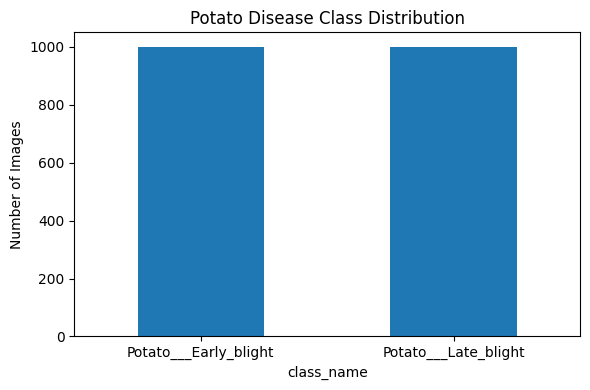

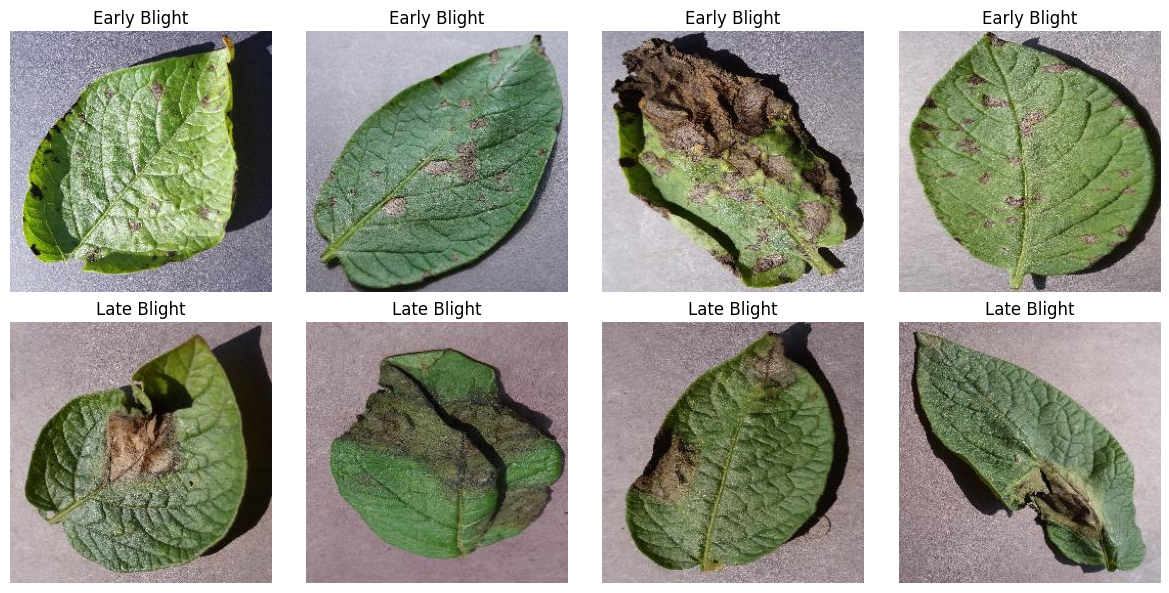


=== CELL 2 SUMMARY ===
Early Blight : 1000
Late Blight  : 1000
Total        : 2000
Class balance: 1.00:1
Figures saved: /content/PlantVillage-Dataset/raw/outputs/figures
Table saved  : /content/PlantVillage-Dataset/raw/outputs/tables/class_distribution.csv


In [4]:
# CELL 2: Visualise and save class distribution + sample images

import matplotlib.pyplot as plt
from pathlib import Path

OUT = ROOT / "outputs"
FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

counts = potato_df["class_name"].value_counts()

# Save class summary table
class_table = counts.rename("Image_Count").reset_index()
class_table.columns = ["Class", "Image_Count"]
class_table.to_csv(TAB_DIR / "class_distribution.csv", index=False)

# Figure 1: Class distribution
plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Potato Disease Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: Sample images
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for r, cls in enumerate(TARGETS):
    samples = potato_df[potato_df["class_name"] == cls].sample(4, random_state=42)

    for c, path in enumerate(samples["filepath"]):
        axes[r, c].imshow(Image.open(path))
        axes[r, c].axis("off")
        axes[r, c].set_title("Early Blight" if "Early" in cls else "Late Blight")

plt.tight_layout()
plt.savefig(FIG_DIR / "sample_images.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== CELL 2 SUMMARY ===")
print(f"Early Blight : {counts['Potato___Early_blight']}")
print(f"Late Blight  : {counts['Potato___Late_blight']}")
print(f"Total        : {len(potato_df)}")
print("Class balance: 1.00:1")
print(f"Figures saved: {FIG_DIR}")
print(f"Table saved  : {TAB_DIR / 'class_distribution.csv'}")

In [5]:
# Feedback addition: explicit 5Vs profile
dataset_mib = potato_df.bytes.sum() / 2**20
dimensions = ", ".join(f"{w}x{h}: {n}" for (w,h), n in potato_df.groupby(["width","height"]).size().items())
formats = ", ".join(f"{k}: {v}" for k,v in potato_df.extension.value_counts().items())
five_vs_df = pd.DataFrame([
    ["Volume", f"2,000 images; 1,000/class; {dataset_mib:.2f} MiB; {dimensions}; {formats}"],
    ["Velocity", "Static pinned training corpus; a future service would receive individual uploads on demand."],
    ["Variety", "Two disease labels, RGB appearances/orientations, segmented variants, and less-controlled PlantDoc imagery."],
    ["Veracity", "Public labels; corruption, hashes, leaf-group leakage, balance, quality and domain limits are audited."],
    ["Value", "Preliminary Early-vs-Late triage and research with probabilities and escalation—not diagnosis/treatment."],
], columns=["V", "Project-specific description"])
five_vs_df.to_csv(TAB_DIR/"five_vs_summary.csv", index=False)
display(five_vs_df)


,V,Project-specific description
0,Volume,"2,000 images; 1,000/class; 34.71 MiB; 256x256:..."
1,Velocity,Static pinned training corpus; a future servic...
2,Variety,"Two disease labels, RGB appearances/orientatio..."
3,Veracity,"Public labels; corruption, hashes, leaf-group ..."
4,Value,Preliminary Early-vs-Late triage and research ...


In [6]:
# CELL 3: Official leaf-group-aware 70/15/15 split before augmentation
import json, random
import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
with open(LEAF_MAP_FILE, encoding="utf-8") as handle:
    raw_leaf_map = json.load(handle)
leaf_lookup = {}
for leaf_key, memberships in raw_leaf_map.items():
    for membership in memberships:
        class_name, leaf_number = membership.rsplit(":::", 1)
        leaf_lookup[(leaf_key.lower(), class_name)] = f"{class_name}::{leaf_number}"

def leaf_group(row):
    key = Path(row.filepath).stem.split("___", 1)[-1].lower()
    return leaf_lookup.get((key, row.class_name))

potato_df["leaf_group"] = potato_df.apply(leaf_group, axis=1)
assert potato_df.leaf_group.notna().all()
assert potato_df.leaf_group.nunique() == 500
assert potato_df.groupby("leaf_group").size().eq(4).all()
rng = np.random.default_rng(SEED)
parts = {"train": [], "validation": [], "test": []}
for label in [0, 1]:
    groups = np.array(sorted(potato_df.loc[potato_df.label == label, "leaf_group"].unique()))
    rng.shuffle(groups)
    n_val_groups = 37 if label == 0 else 38
    selections = {
        "train": set(groups[:175]),
        "validation": set(groups[175:175+n_val_groups]),
        "test": set(groups[175+n_val_groups:]),
    }
    class_frame = potato_df[potato_df.label == label]
    for split_name, selected in selections.items():
        parts[split_name].append(class_frame[class_frame.leaf_group.isin(selected)])
train_df = pd.concat(parts["train"]).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat(parts["validation"]).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(parts["test"]).sample(frac=1, random_state=SEED).reset_index(drop=True)
group_sets = {"Train": set(train_df.leaf_group), "Validation": set(val_df.leaf_group), "Test": set(test_df.leaf_group)}
group_overlap_df = pd.DataFrame([
    ["Train-Validation", len(group_sets["Train"] & group_sets["Validation"])],
    ["Train-Test", len(group_sets["Train"] & group_sets["Test"])],
    ["Validation-Test", len(group_sets["Validation"] & group_sets["Test"])],
], columns=["Comparison", "Shared_Leaf_Groups"])
assert group_overlap_df.Shared_Leaf_Groups.sum() == 0
for name, frame in [("train",train_df),("validation",val_df),("test",test_df)]:
    frame.to_csv(TAB_DIR/f"{name}_split.csv", index=False)
group_overlap_df.to_csv(TAB_DIR/"leaf_group_overlap_audit.csv", index=False)
split_summary = pd.DataFrame({
    "Split":["Train","Validation","Test"], "Total":[len(train_df),len(val_df),len(test_df)],
    "Early_Blight":[(d.label==0).sum() for d in [train_df,val_df,test_df]],
    "Late_Blight":[(d.label==1).sum() for d in [train_df,val_df,test_df]],
    "Leaf_Groups":[d.leaf_group.nunique() for d in [train_df,val_df,test_df]],
})
split_summary.to_csv(TAB_DIR/"split_summary.csv", index=False)
display(split_summary); display(group_overlap_df)


,Split,Total,Early_Blight,Late_Blight,Leaf_Groups
0,Train,1400,700,700,350
1,Validation,300,148,152,75
2,Test,300,152,148,75


,Comparison,Shared_Leaf_Groups
0,Train-Validation,0
1,Train-Test,0
2,Validation-Test,0


In [7]:
# CELL 4: Build PyTorch datasets and dataloaders

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE, BATCH = 224, 32

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class PotatoDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row.filepath).convert("RGB")
        return self.transform(img), torch.tensor(row.label, dtype=torch.float32)

train_set = PotatoDataset(train_df, train_tfms)
val_set   = PotatoDataset(val_df, eval_tfms)
test_set  = PotatoDataset(test_df, eval_tfms)

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=BATCH, shuffle=False)

xb, yb = next(iter(train_loader))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n=== CELL 4 SUMMARY ===")
print(f"Train/Val/Test : {len(train_set)}/{len(val_set)}/{len(test_set)}")
print(f"Batch shape    : {tuple(xb.shape)}")
print(f"Image size     : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size     : {BATCH}")
print(f"Label values   : {sorted(train_df.label.unique())}")
print(f"Device         : {device}")


=== CELL 4 SUMMARY ===
Train/Val/Test : 1400/300/300
Batch shape    : (32, 3, 224, 224)
Image size     : 224x224
Batch size     : 32
Label values   : [np.int64(0), np.int64(1)]
Device         : cuda


# Leakage-controlled evaluation protocol

Splitting precedes augmentation, and every underlying leaf belongs to exactly one split. Training fits parameters; validation controls early stopping, ablations, and thresholds; test evaluation follows locked choices. PlantDoc is never used for fitting/tuning. It is an exploratory external-domain test, not evidence of field safety.


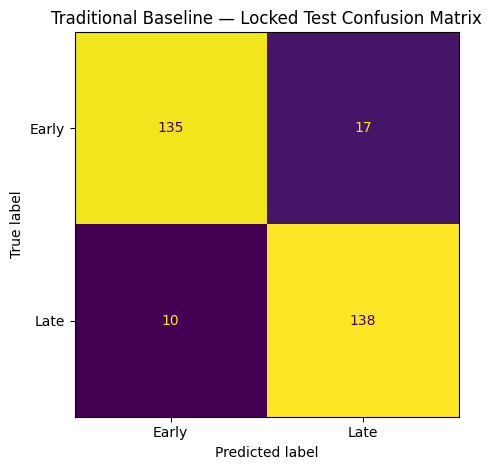

,Accuracy,Precision_Late,Recall_Late,Specificity_Early,F1_Late,Balanced_Accuracy,ROC_AUC,Average_Precision,Threshold,TN,FP,FN,TP
0,0.91,0.8903,0.9324,0.8882,0.9109,0.9103,0.9624,0.9597,0.7,135,17,10,138


In [8]:
# Traditional baseline: 32x32 grayscale pixels + logistic regression
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay)

MODEL_DIR = OUT/"models"; MODEL_DIR.mkdir(parents=True, exist_ok=True)

def select_f1_threshold(labels, probabilities):
    grid = np.arange(.05, .951, .01)
    scores = np.array([f1_score(labels, probabilities >= t, zero_division=0) for t in grid])
    candidates = np.flatnonzero(scores == scores.max())
    return float(grid[candidates[np.argmin(abs(grid[candidates]-.5))]])

def metric_record(labels, probabilities, threshold):
    prediction = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, prediction, labels=[0,1]).ravel()
    return {"Accuracy":accuracy_score(labels,prediction),
        "Precision_Late":precision_score(labels,prediction,zero_division=0),
        "Recall_Late":recall_score(labels,prediction,zero_division=0),
        "Specificity_Early":tn/(tn+fp), "F1_Late":f1_score(labels,prediction,zero_division=0),
        "Balanced_Accuracy":balanced_accuracy_score(labels,prediction),
        "ROC_AUC":roc_auc_score(labels,probabilities),
        "Average_Precision":average_precision_score(labels,probabilities),
        "Threshold":threshold, "TN":tn, "FP":fp, "FN":fn, "TP":tp}

def grayscale_features(frame, size=(32,32)):
    return np.stack([np.asarray(Image.open(p).convert("L").resize(size),dtype=np.float32).ravel()/255 for p in frame.filepath])

baseline_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1500,solver="liblinear",random_state=SEED))
baseline_model.fit(grayscale_features(train_df), train_df.label)
baseline_val_prob = baseline_model.predict_proba(grayscale_features(val_df))[:,1]
BASELINE_THRESHOLD = select_f1_threshold(val_df.label.to_numpy(), baseline_val_prob)
baseline_test_prob = baseline_model.predict_proba(grayscale_features(test_df))[:,1]
baseline_test_pred = (baseline_test_prob >= BASELINE_THRESHOLD).astype(int)
baseline_metrics = metric_record(test_df.label.to_numpy(), baseline_test_prob, BASELINE_THRESHOLD)
pd.DataFrame([{"Model":"Logistic grayscale baseline",**baseline_metrics}]).to_csv(TAB_DIR/"baseline_logistic_test_metrics.csv",index=False)
pd.DataFrame({"filepath":test_df.filepath,"true_label":test_df.label,"late_probability":baseline_test_prob,"prediction":baseline_test_pred}).to_csv(TAB_DIR/"baseline_logistic_test_predictions.csv",index=False)
joblib.dump(baseline_model, MODEL_DIR/"baseline_logistic.joblib")
ConfusionMatrixDisplay.from_predictions(test_df.label,baseline_test_pred,display_labels=["Early","Late"],colorbar=False)
plt.title("Traditional Baseline — Locked Test Confusion Matrix"); plt.tight_layout()
plt.savefig(FIG_DIR/"baseline_logistic_confusion_matrix.png",dpi=300,bbox_inches="tight"); plt.show()
display(pd.DataFrame([baseline_metrics]).round(4))


In [9]:
# CELL 5: Lightweight CNN definition and conditional weighting
import torch.nn as nn

class PotatoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.ReLU(),nn.MaxPool2d(2))
        self.classifier = nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(.30),nn.Linear(128,1))
    def forward(self,x): return self.classifier(self.features(x)).squeeze(1)

model = PotatoCNN().to(device)
train_counts = train_df.label.value_counts().sort_index()
imbalance_ratio = train_counts.max()/train_counts.min()
USE_CLASS_WEIGHT = imbalance_ratio > 1.10
if USE_CLASS_WEIGHT:
    pos_weight = torch.tensor([train_counts[0]/train_counts[1]],dtype=torch.float32,device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
else:
    criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_config_df = pd.DataFrame([
    ["Input","224x224 RGB; ImageNet normalisation"],
    ["Convolutions","3 blocks; 32/64/128 filters; 3x3; ReLU; 2x2 max-pool"],
    ["Regularisation","Dropout=.30; train-only flips, rotation, random crop"],
    ["Loss","BCEWithLogitsLoss"+(" + positive weight" if USE_CLASS_WEIGHT else "; no weight (balanced)")],
    ["Optimiser","Adam; lr=.001"],["Batch / maximum epochs","32 / 20"],
    ["Early stopping","Validation loss; patience=5; restore best weights"],
    ["Trainable parameters",f"{params:,}"],
],columns=["Setting","Value"])
model_config_df.to_csv(TAB_DIR/"custom_cnn_configuration.csv",index=False)
display(model_config_df)
print("Train counts:",train_counts.to_dict(),"imbalance ratio:",round(imbalance_ratio,3),"weighted:",USE_CLASS_WEIGHT)


,Setting,Value
0,Input,224x224 RGB; ImageNet normalisation
1,Convolutions,3 blocks; 32/64/128 filters; 3x3; ReLU; 2x2 ma...
2,Regularisation,"Dropout=.30; train-only flips, rotation, rando..."
3,Loss,BCEWithLogitsLoss; no weight (balanced)
4,Optimiser,Adam; lr=.001
5,Batch / maximum epochs,32 / 20
6,Early stopping,Validation loss; patience=5; restore best weights
7,Trainable parameters,"93,377"


Train counts: {0: 700, 1: 700} imbalance ratio: 1.0 weighted: False


In [10]:
# CELL 6: Train CNN with early stopping

import copy, numpy as np, pandas as pd
from sklearn.metrics import f1_score

EPOCHS, PATIENCE = 20, 5
best_loss, wait, best_state = np.inf, 0, None
history = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_set)

    model.eval()
    val_loss, preds, labels = 0, [], []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)

            val_loss += criterion(logits, y).item() * x.size(0)
            preds.extend((torch.sigmoid(logits) >= 0.5).cpu().numpy())
            labels.extend(y.cpu().numpy())

    val_loss /= len(val_set)
    val_acc = np.mean(np.array(preds) == np.array(labels))
    val_f1 = f1_score(labels, preds)

    history.append([epoch+1, train_loss, val_loss, val_acc, val_f1])

    print(f"Epoch {epoch+1:02d} | train={train_loss:.4f} | "
          f"val={val_loss:.4f} | acc={val_acc:.4f} | f1={val_f1:.4f}")

    if val_loss < best_loss:
        best_loss, wait = val_loss, 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)

MODEL_DIR = OUT / "models"
MODEL_DIR.mkdir(exist_ok=True)

torch.save(model.state_dict(), MODEL_DIR / "best_potato_cnn.pt")

history_df = pd.DataFrame(
    history,
    columns=["epoch", "train_loss", "val_loss", "val_accuracy", "val_f1"]
)
history_df.to_csv(TAB_DIR / "training_history.csv", index=False)

best_epoch = history_df.loc[history_df["val_loss"].idxmin(), "epoch"]

print("\n=== CELL 6 SUMMARY ===")
print(f"Epochs run      : {len(history_df)}")
print(f"Best epoch      : {best_epoch}")
print(f"Best val loss   : {history_df.val_loss.min():.4f}")
print(f"Best val acc    : {history_df.val_accuracy.max():.4f}")
print(f"Best val F1     : {history_df.val_f1.max():.4f}")
print(f"Model saved     : {MODEL_DIR / 'best_potato_cnn.pt'}")
print(f"History saved   : {TAB_DIR / 'training_history.csv'}")

Epoch 01 | train=0.4685 | val=0.2586 | acc=0.9167 | f1=0.9129
Epoch 02 | train=0.2859 | val=0.1821 | acc=0.9367 | f1=0.9393
Epoch 03 | train=0.2666 | val=0.2053 | acc=0.9233 | f1=0.9199
Epoch 04 | train=0.1993 | val=0.1006 | acc=0.9600 | f1=0.9610
Epoch 05 | train=0.1384 | val=0.0635 | acc=0.9767 | f1=0.9773
Epoch 06 | train=0.1140 | val=0.0483 | acc=0.9867 | f1=0.9868
Epoch 07 | train=0.1225 | val=0.0662 | acc=0.9767 | f1=0.9775
Epoch 08 | train=0.1157 | val=0.0650 | acc=0.9833 | f1=0.9835
Epoch 09 | train=0.1087 | val=0.0624 | acc=0.9767 | f1=0.9767
Epoch 10 | train=0.0842 | val=0.0348 | acc=0.9900 | f1=0.9902
Epoch 11 | train=0.0925 | val=0.0510 | acc=0.9767 | f1=0.9767
Epoch 12 | train=0.0723 | val=0.0401 | acc=0.9833 | f1=0.9838
Epoch 13 | train=0.0765 | val=0.0490 | acc=0.9833 | f1=0.9838
Epoch 14 | train=0.0755 | val=0.1058 | acc=0.9667 | f1=0.9682
Epoch 15 | train=0.0722 | val=0.1139 | acc=0.9667 | f1=0.9682
Early stopping triggered.

=== CELL 6 SUMMARY ===
Epochs run      : 15

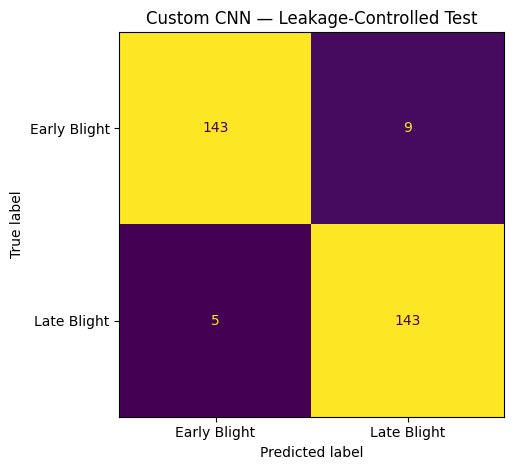

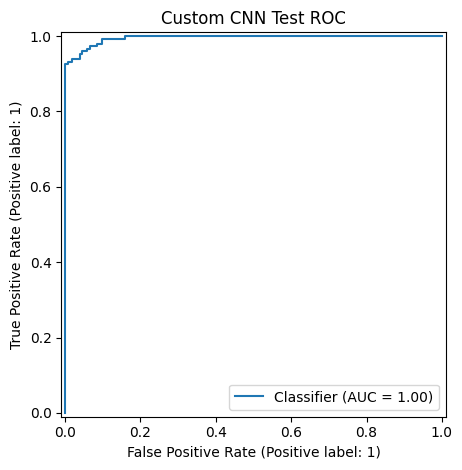

Threshold=0.38 Accuracy=0.9533 Precision(Late)=0.9408 Recall(Late)=0.9662 F1=0.9533 AUC=0.9952
TN/FP/FN/TP=143/9/5/143; FN means Late predicted as Early


In [11]:
# CELL 7: Select threshold on validation, then evaluate locked custom CNN on test
from sklearn.metrics import RocCurveDisplay

def torch_probabilities(network,loader):
    network.eval(); labels=[]; probabilities=[]
    with torch.no_grad():
        for x,y in loader:
            logits=network(x.to(device))
            if logits.ndim > 1: logits=logits.squeeze(1)
            probabilities.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(y.numpy())
    return np.asarray(labels).astype(int),np.asarray(probabilities)

val_true_custom,val_prob_custom = torch_probabilities(model,val_loader)
CUSTOM_THRESHOLD = select_f1_threshold(val_true_custom,val_prob_custom)
y_true,y_prob = torch_probabilities(model,test_loader)
y_pred = (y_prob >= CUSTOM_THRESHOLD).astype(int)
custom_metrics = metric_record(y_true,y_prob,CUSTOM_THRESHOLD)
acc=custom_metrics["Accuracy"]; prec=custom_metrics["Precision_Late"]
rec=custom_metrics["Recall_Late"]; f1=custom_metrics["F1_Late"]; auc=custom_metrics["ROC_AUC"]
cm=confusion_matrix(y_true,y_pred,labels=[0,1]); tn,fp,fn,tp=cm.ravel()
metrics_df=pd.DataFrame({"Metric":list(custom_metrics),"Value":list(custom_metrics.values())})
metrics_df.to_csv(TAB_DIR/"test_metrics.csv",index=False)
pd.DataFrame([{"Threshold":CUSTOM_THRESHOLD,"Selected_On":"Validation","Validation_F1":f1_score(val_true_custom,val_prob_custom>=CUSTOM_THRESHOLD)}]).to_csv(TAB_DIR/"custom_validation_threshold.csv",index=False)
ConfusionMatrixDisplay(cm,display_labels=["Early Blight","Late Blight"]).plot(colorbar=False)
plt.title("Custom CNN — Leakage-Controlled Test"); plt.tight_layout()
plt.savefig(FIG_DIR/"test_confusion_matrix.png",dpi=300,bbox_inches="tight"); plt.show()
RocCurveDisplay.from_predictions(y_true,y_prob); plt.title("Custom CNN Test ROC"); plt.tight_layout()
plt.savefig(FIG_DIR/"test_roc_curve.png",dpi=300,bbox_inches="tight"); plt.show()
print(f"Threshold={CUSTOM_THRESHOLD:.2f} Accuracy={acc:.4f} Precision(Late)={prec:.4f} Recall(Late)={rec:.4f} F1={f1:.4f} AUC={auc:.4f}")
print(f"TN/FP/FN/TP={tn}/{fp}/{fn}/{tp}; FN means Late predicted as Early")


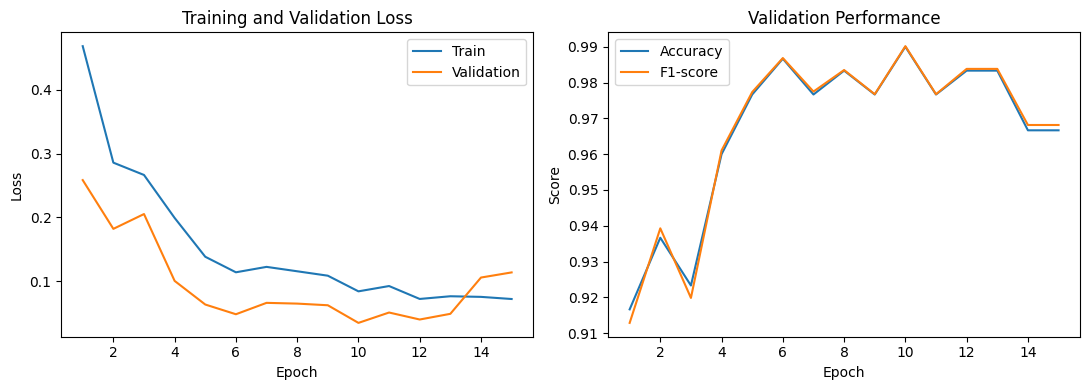


=== CELL 8 SUMMARY ===
Best epoch       : 10
Best val loss    : 0.0348
Best val accuracy: 0.9900
Best val F1      : 0.9902
Figure saved     : /content/PlantVillage-Dataset/raw/outputs/figures/training_history.png


In [12]:
# CELL 8: Plot and save training history

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(history_df.epoch, history_df.train_loss, label="Train")
ax[0].plot(history_df.epoch, history_df.val_loss, label="Validation")
ax[0].set(title="Training and Validation Loss", xlabel="Epoch", ylabel="Loss")
ax[0].legend()

ax[1].plot(history_df.epoch, history_df.val_accuracy, label="Accuracy")
ax[1].plot(history_df.epoch, history_df.val_f1, label="F1-score")
ax[1].set(title="Validation Performance", xlabel="Epoch", ylabel="Score")
ax[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "training_history.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== CELL 8 SUMMARY ===")
print(f"Best epoch       : {int(history_df.loc[history_df.val_loss.idxmin(),'epoch'])}")
print(f"Best val loss    : {history_df.val_loss.min():.4f}")
print(f"Best val accuracy: {history_df.val_accuracy.max():.4f}")
print(f"Best val F1      : {history_df.val_f1.max():.4f}")
print(f"Figure saved     : {FIG_DIR / 'training_history.png'}")

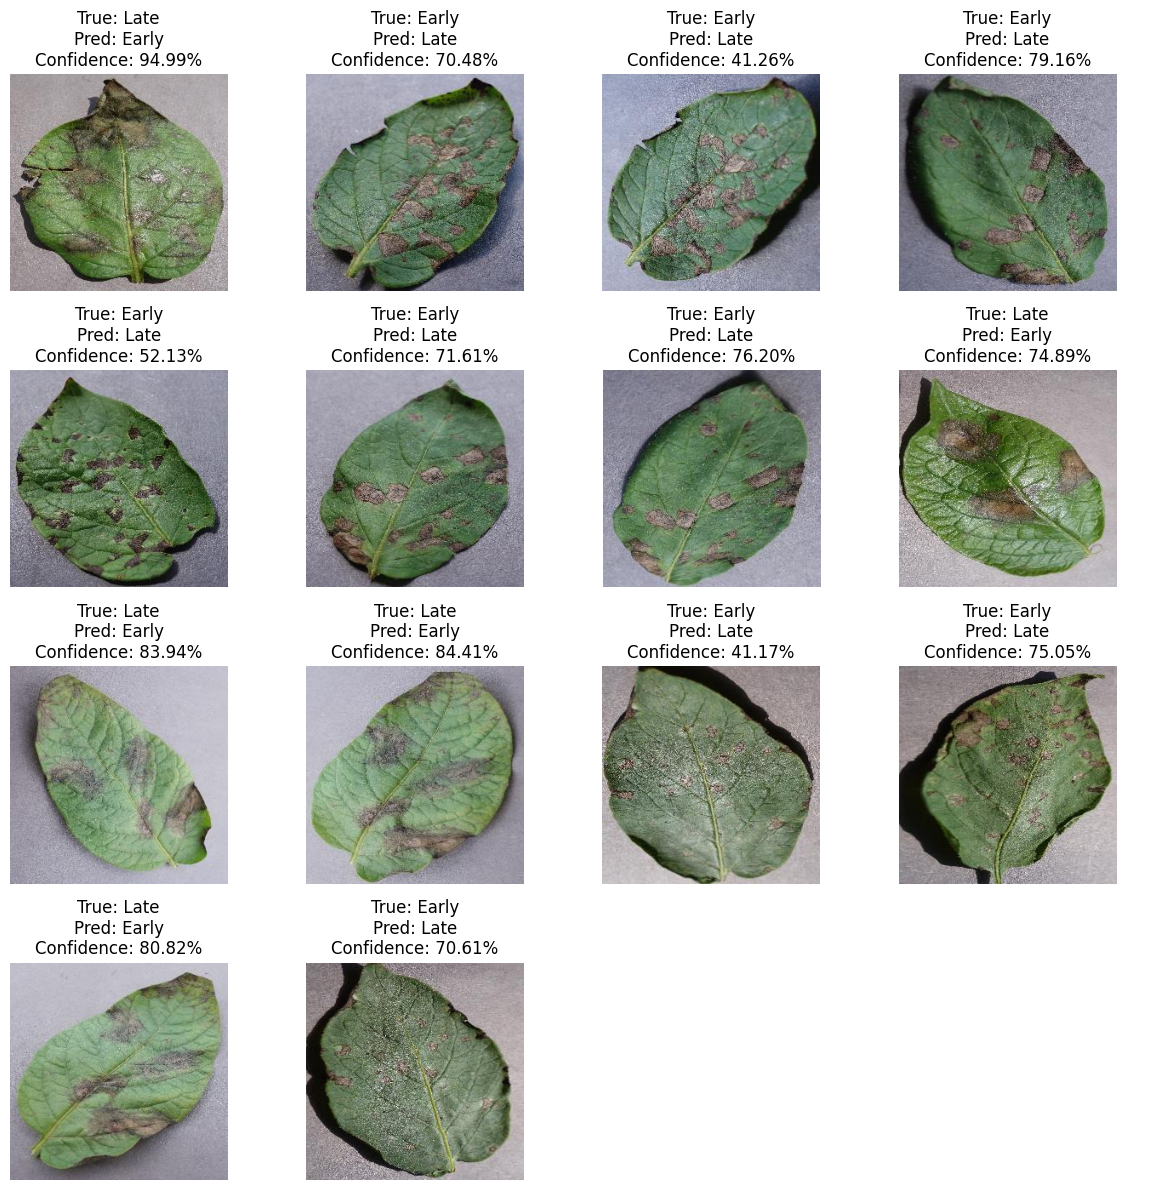

Misclassified: 14/300; Early→Late: 9; Late→Early: 5


In [13]:
# CELL 9: Inspect and save misclassified test images
results=test_df.copy().reset_index(drop=True)
results["prob_late"]=y_prob; results["pred"]=y_pred
errors=results[results.label != results.pred].copy()
errors.to_csv(TAB_DIR/"misclassified_samples.csv",index=False)
if len(errors):
    columns=min(4,len(errors)); rows=int(np.ceil(len(errors)/columns))
    fig,axes=plt.subplots(rows,columns,figsize=(3*columns,3*rows),squeeze=False)
    for ax in axes.flat: ax.axis("off")
    for ax,(_,row) in zip(axes.flat,errors.iterrows()):
        ax.imshow(Image.open(row.filepath)); ax.axis("off")
        true_name="Early" if row.label==0 else "Late"; pred_name="Early" if row.pred==0 else "Late"
        confidence=row.prob_late if row.pred==1 else 1-row.prob_late
        ax.set_title(f"True: {true_name}\nPred: {pred_name}\nConfidence: {confidence:.2%}")
    plt.tight_layout(); plt.savefig(FIG_DIR/"misclassified_images.png",dpi=300,bbox_inches="tight"); plt.show()
else:
    plt.figure(figsize=(6,2)); plt.text(.5,.5,"No test errors to display",ha="center",va="center"); plt.axis("off")
    plt.tight_layout(); plt.savefig(FIG_DIR/"misclassified_images.png",dpi=300,bbox_inches="tight"); plt.show()
print(f"Misclassified: {len(errors)}/{len(results)}; Early→Late: {((errors.label==0)&(errors.pred==1)).sum()}; Late→Early: {((errors.label==1)&(errors.pred==0)).sum()}")


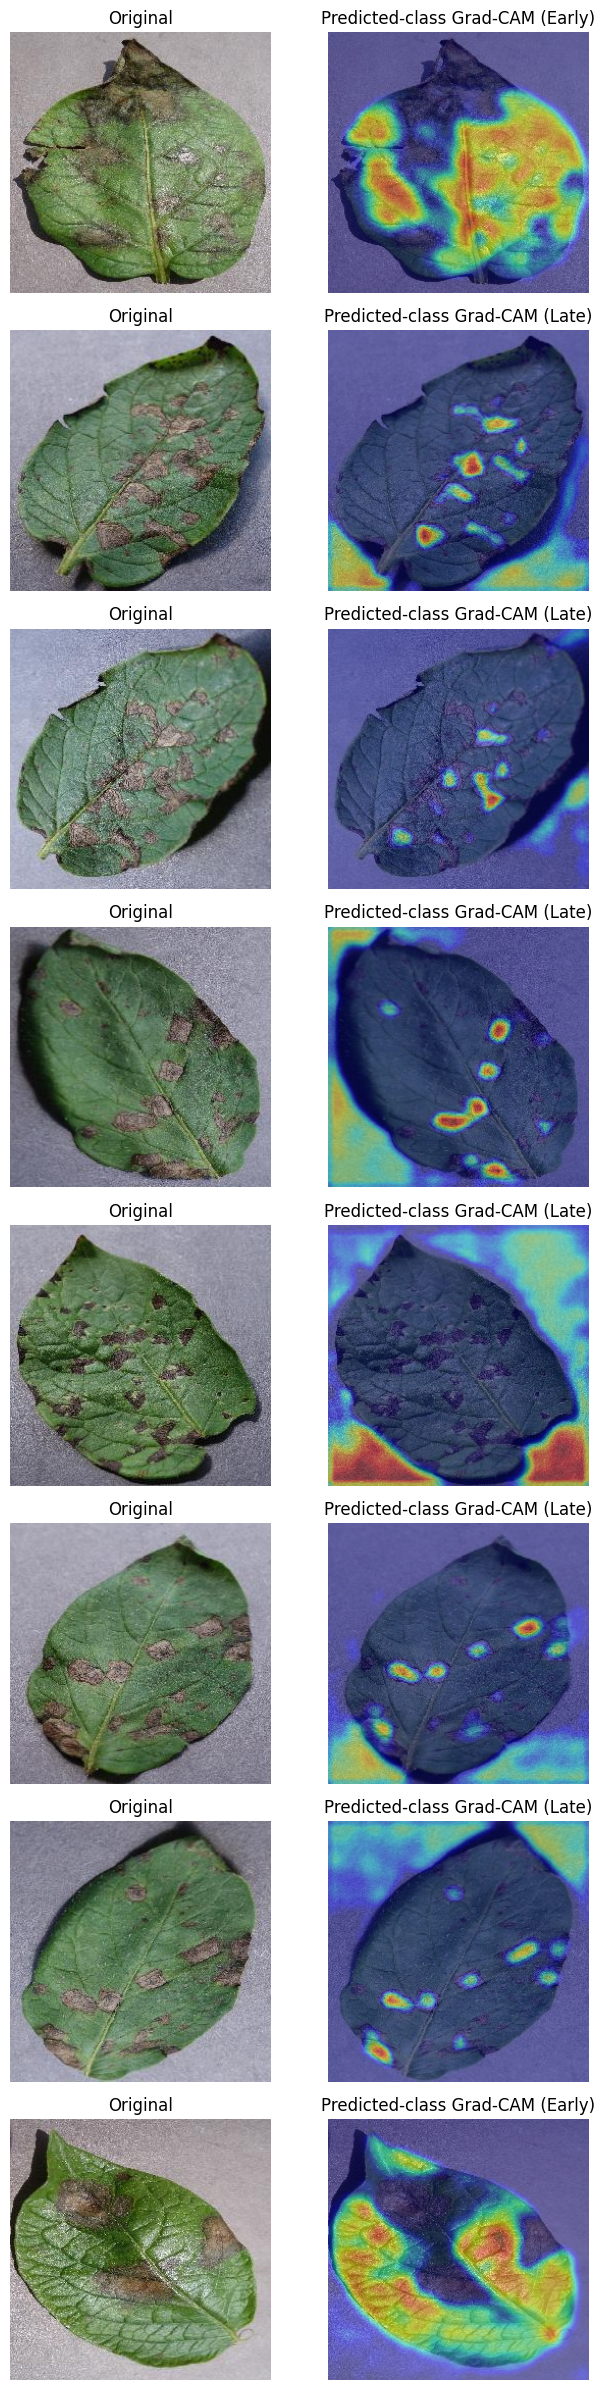

Grad-CAM examples: 8 source: test errors


In [14]:
# CELL 10: Predicted-class Grad-CAM with a zero-error fallback
import torch.nn.functional as F

def gradcam(path):
    activations=[]; gradients=[]; target_layer=model.features[6]
    forward_handle=target_layer.register_forward_hook(lambda module,inputs,output: activations.append(output))
    backward_handle=target_layer.register_full_backward_hook(lambda module,grad_input,grad_output: gradients.append(grad_output[0]))
    image=Image.open(path).convert("RGB"); x=eval_tfms(image).unsqueeze(0).to(device)
    model.zero_grad(); logit=model(x); probability=float(torch.sigmoid(logit).item())
    predicted=int(probability>=CUSTOM_THRESHOLD); (logit if predicted==1 else -logit).backward()
    weights=gradients[0].mean((2,3),keepdim=True)
    cam=F.relu((weights*activations[0]).sum(1)).squeeze(); cam=cam/(cam.max()+1e-8)
    cam=F.interpolate(cam[None,None],image.size[::-1],mode="bilinear",align_corners=False).squeeze().detach().cpu().numpy()
    forward_handle.remove(); backward_handle.remove()
    return image,cam,predicted

# Explain mistakes when present; otherwise explain the least-confident test cases.
xai_examples=errors.copy() if len(errors) else results.assign(confidence=np.maximum(y_prob,1-y_prob)).nsmallest(4,"confidence")
xai_examples=xai_examples.head(8)
columns=2; rows=len(xai_examples)
fig,axes=plt.subplots(rows,columns,figsize=(7,3*rows),squeeze=False)
for row_index,(_,row) in enumerate(xai_examples.iterrows()):
    image,cam,predicted=gradcam(row.filepath)
    axes[row_index,0].imshow(image); axes[row_index,0].axis("off"); axes[row_index,0].set_title("Original")
    axes[row_index,1].imshow(image); axes[row_index,1].imshow(cam,cmap="jet",alpha=.45); axes[row_index,1].axis("off")
    axes[row_index,1].set_title(f"Predicted-class Grad-CAM ({'Late' if predicted else 'Early'})")
plt.tight_layout(); plt.savefig(FIG_DIR/"gradcam_predicted_class.png",dpi=300,bbox_inches="tight"); plt.show()
print("Grad-CAM examples:",len(xai_examples),"source:","test errors" if len(errors) else "least-confident test cases")


In [15]:
# CELL 11: Class-wise classification report

from sklearn.metrics import classification_report

report = classification_report(
    y_true, y_pred,
    target_names=["Early Blight", "Late Blight"],
    output_dict=True
)

report_df = pd.DataFrame(report).T
report_df.to_csv(TAB_DIR / "classification_report.csv")

display(report_df.round(4))

print("\n=== CELL 11 SUMMARY ===")
print(f"Early Blight F1 : {report_df.loc['Early Blight','f1-score']:.4f}")
print(f"Late Blight F1  : {report_df.loc['Late Blight','f1-score']:.4f}")
print(f"Macro F1        : {report_df.loc['macro avg','f1-score']:.4f}")
print(f"Weighted F1     : {report_df.loc['weighted avg','f1-score']:.4f}")
print(f"Table saved     : {TAB_DIR / 'classification_report.csv'}")

,precision,recall,f1-score,support
Early Blight,0.9662,0.9408,0.9533,152.0000
Late Blight,0.9408,0.9662,0.9533,148.0000
accuracy,0.9533,0.9533,0.9533,0.9533
macro avg,0.9535,0.9535,0.9533,300.0000
weighted avg,0.9537,0.9533,0.9533,300.0000



=== CELL 11 SUMMARY ===
Early Blight F1 : 0.9533
Late Blight F1  : 0.9533
Macro F1        : 0.9533
Weighted F1     : 0.9533
Table saved     : /content/PlantVillage-Dataset/raw/outputs/tables/classification_report.csv


In [16]:
# CELL 12: Cross-split duplicate audit

import hashlib
import numpy as np
from PIL import Image

def md5(p):
    with open(p, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def dhash(p):
    img = Image.open(p).convert("L").resize((9, 8))
    a = np.array(img)
    bits = a[:, :-1] > a[:, 1:]
    return sum(int(v) << i for i, v in enumerate(bits.flatten()))

def audit(a, b):
    A = [(md5(p), dhash(p)) for p in a.filepath]
    B = [(md5(p), dhash(p)) for p in b.filepath]

    exact = len({x[0] for x in A} & {x[0] for x in B})
    near = sum(min((x[1] ^ y[1]).bit_count() for y in B) <= 4 for x in A)
    return exact, near

tv = audit(train_df, val_df)
tt = audit(train_df, test_df)
vt = audit(val_df, test_df)

audit_df = pd.DataFrame([
    ["Train-Val", *tv],
    ["Train-Test", *tt],
    ["Val-Test", *vt]
], columns=["Comparison", "Exact_Duplicates", "Near_Duplicates"])

audit_df.to_csv(TAB_DIR / "duplicate_audit.csv", index=False)
display(audit_df)

print("\n=== CELL 12 SUMMARY ===")
print(f"Train-Val  exact/near : {tv[0]}/{tv[1]}")
print(f"Train-Test exact/near : {tt[0]}/{tt[1]}")
print(f"Val-Test   exact/near : {vt[0]}/{vt[1]}")
print("Near threshold        : dHash distance <= 4")
print(f"Table saved           : {TAB_DIR / 'duplicate_audit.csv'}")

,Comparison,Exact_Duplicates,Near_Duplicates
0,Train-Val,0,0
1,Train-Test,0,0
2,Val-Test,0,0



=== CELL 12 SUMMARY ===
Train-Val  exact/near : 0/0
Train-Test exact/near : 0/0
Val-Test   exact/near : 0/0
Near threshold        : dHash distance <= 4
Table saved           : /content/PlantVillage-Dataset/raw/outputs/tables/duplicate_audit.csv


In [17]:
# CELL 13: Robustness test on segmented test images

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

SEG_DIR = ROOT / "segmented"
seg_true, seg_prob = [], []

model.eval()

with torch.no_grad():
    for _, row in test_df.iterrows():
        p = Path(row.filepath)
        seg_path = SEG_DIR / row.class_name / f"{p.stem}_final_masked.jpg"

        img = eval_tfms(Image.open(seg_path).convert("RGB")).unsqueeze(0).to(device)
        prob = torch.sigmoid(model(img)).item()

        seg_true.append(int(row.label))
        seg_prob.append(prob)

seg_true = np.array(seg_true)
seg_prob = np.array(seg_prob)
seg_pred = (seg_prob >= 0.5).astype(int)

seg_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [
        accuracy_score(seg_true, seg_pred),
        precision_score(seg_true, seg_pred),
        recall_score(seg_true, seg_pred),
        f1_score(seg_true, seg_pred),
        roc_auc_score(seg_true, seg_prob)
    ]
})

seg_metrics.to_csv(TAB_DIR / "segmented_test_metrics.csv", index=False)
display(seg_metrics.round(4))

print("\n=== CELL 13 SUMMARY ===")
for _, r in seg_metrics.iterrows():
    print(f"{r.Metric:<10}: {r.Value:.4f}")
print(f"Images tested : {len(seg_true)}")
print(f"Table saved   : {TAB_DIR / 'segmented_test_metrics.csv'}")

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Value
0,Accuracy,0.5067
1,Precision,0.0000
2,Recall,0.0000
3,F1-score,0.0000
4,ROC-AUC,0.9566



=== CELL 13 SUMMARY ===
Accuracy  : 0.5067
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.9566
Images tested : 300
Table saved   : /content/PlantVillage-Dataset/raw/outputs/tables/segmented_test_metrics.csv


In [18]:
# CELL 14: Calibrate segmented threshold on validation set, test once

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np, pandas as pd

def segmented_probs(df):
    ys, probs = [], []
    model.eval()
    with torch.no_grad():
        for _, r in df.iterrows():
            p = Path(r.filepath)
            sp = SEG_DIR / r.class_name / f"{p.stem}_final_masked.jpg"
            x = eval_tfms(Image.open(sp).convert("RGB")).unsqueeze(0).to(device)
            probs.append(torch.sigmoid(model(x)).item())
            ys.append(int(r.label))
    return np.array(ys), np.array(probs)

yv, pv = segmented_probs(val_df)

thresholds = np.arange(0.01, 1.00, 0.01)
best_t = thresholds[np.argmax([f1_score(yv, pv >= t) for t in thresholds])]

pred = (seg_prob >= best_t).astype(int)

cal_metrics = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score","ROC-AUC"],
    "Value": [
        accuracy_score(seg_true,pred),
        precision_score(seg_true,pred),
        recall_score(seg_true,pred),
        f1_score(seg_true,pred),
        roc_auc_score(seg_true,seg_prob)
    ]
})

cal_metrics.to_csv(TAB_DIR / "segmented_calibrated_metrics.csv", index=False)

print("\n=== CELL 14 SUMMARY ===")
print(f"Validation-selected threshold : {best_t:.2f}")
print(f"Test Accuracy                 : {cal_metrics.Value[0]:.4f}")
print(f"Test Precision                : {cal_metrics.Value[1]:.4f}")
print(f"Test Recall                   : {cal_metrics.Value[2]:.4f}")
print(f"Test F1                       : {cal_metrics.Value[3]:.4f}")
print(f"Test ROC-AUC                  : {cal_metrics.Value[4]:.4f}")
print(f"Table saved                   : {TAB_DIR / 'segmented_calibrated_metrics.csv'}")


=== CELL 14 SUMMARY ===
Validation-selected threshold : 0.01
Test Accuracy                 : 0.8800
Test Precision                : 0.8784
Test Recall                   : 0.8784
Test F1                       : 0.8784
Test ROC-AUC                  : 0.9566
Table saved                   : /content/PlantVillage-Dataset/raw/outputs/tables/segmented_calibrated_metrics.csv


,Dataset,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Original colour,0.9533,0.9408,0.9662,0.9533,0.9952
1,Segmented,0.8800,0.8784,0.8784,0.8784,0.9566


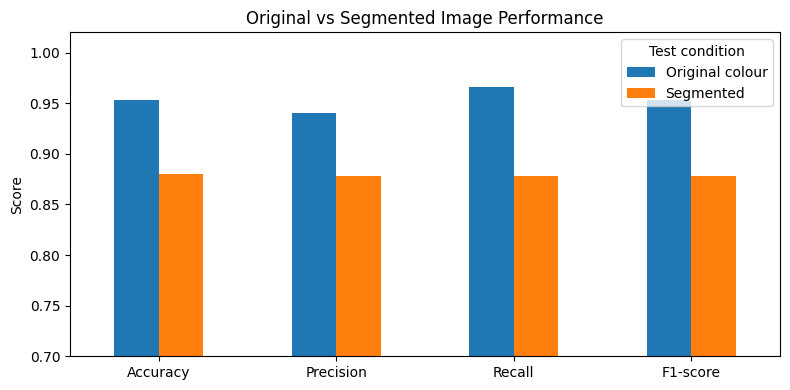


=== CELL 15 SUMMARY ===
Original F1     : 0.9533
Segmented F1    : 0.8784
Original AUC    : 0.9952
Segmented AUC   : 0.9566
Segmented threshold: 0.01
Table saved     : /content/PlantVillage-Dataset/raw/outputs/tables/original_vs_segmented.csv
Figure saved    : /content/PlantVillage-Dataset/raw/outputs/figures/original_vs_segmented.png


In [19]:
# CELL 15: Compare original and segmented test performance

comparison = pd.DataFrame({
    "Dataset": ["Original colour", "Segmented"],
    "Accuracy": [acc, cal_metrics.Value[0]],
    "Precision": [prec, cal_metrics.Value[1]],
    "Recall": [rec, cal_metrics.Value[2]],
    "F1-score": [f1, cal_metrics.Value[3]],
    "ROC-AUC": [auc, cal_metrics.Value[4]]
})

comparison.to_csv(TAB_DIR / "original_vs_segmented.csv", index=False)
display(comparison.round(4))

comparison.set_index("Dataset")[["Accuracy","Precision","Recall","F1-score"]].T.plot(
    kind="bar", figsize=(8,4)
)
plt.ylim(0.7, 1.02)
plt.ylabel("Score")
plt.title("Original vs Segmented Image Performance")
plt.xticks(rotation=0)
plt.legend(title="Test condition")
plt.tight_layout()
plt.savefig(FIG_DIR / "original_vs_segmented.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== CELL 15 SUMMARY ===")
print(f"Original F1     : {f1:.4f}")
print(f"Segmented F1    : {cal_metrics.Value[3]:.4f}")
print(f"Original AUC    : {auc:.4f}")
print(f"Segmented AUC   : {cal_metrics.Value[4]:.4f}")
print(f"Segmented threshold: {best_t:.2f}")
print(f"Table saved     : {TAB_DIR / 'original_vs_segmented.csv'}")
print(f"Figure saved    : {FIG_DIR / 'original_vs_segmented.png'}")

In [20]:
# CELL 16: Dynamic interim summary
summary_text=f"""POTATO BLIGHT — INTERIM LEAKAGE-CONTROLLED SUMMARY
PlantVillage revision: {PLANTVILLAGE_COMMIT}
Task: Early=0; Late=1 (positive)
Images/leaves: {len(potato_df)}/{potato_df.leaf_group.nunique()}
Train/validation/test: {len(train_df)}/{len(val_df)}/{len(test_df)}
Shared leaf groups: {group_overlap_df.Shared_Leaf_Groups.sum()}
Custom parameters: {params:,}; class weighting: {USE_CLASS_WEIGHT}
Custom locked-test accuracy/F1/AUC: {acc:.4f}/{f1:.4f}/{auc:.4f}
Controlled-domain proof of concept only; not diagnosis or treatment advice."""
(OUT/"project_implementation_summary.txt").write_text(summary_text,encoding="utf-8")
print(summary_text)


POTATO BLIGHT — INTERIM LEAKAGE-CONTROLLED SUMMARY
PlantVillage revision: 7f7ecc7e1eaca78107e3affe7cb5abd9427e139a
Task: Early=0; Late=1 (positive)
Images/leaves: 2000/500
Train/validation/test: 1400/300/300
Shared leaf groups: 0
Custom parameters: 93,377; class weighting: False
Custom locked-test accuracy/F1/AUC: 0.9533/0.9533/0.9952
Controlled-domain proof of concept only; not diagnosis or treatment advice.


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 188MB/s]


MobileNet 01 head: train=0.4871 val=0.3241 val_f1=0.9767
MobileNet 02 head: train=0.2768 val=0.2158 val_f1=0.9735
MobileNet 03 head: train=0.1961 val=0.1662 val_f1=0.9769
MobileNet 04 head: train=0.1715 val=0.1384 val_f1=0.9803
MobileNet 05 fine_tune: train=0.0876 val=0.0522 val_f1=0.9836
MobileNet 06 fine_tune: train=0.0486 val=0.0285 val_f1=0.9902
MobileNet 07 fine_tune: train=0.0293 val=0.0222 val_f1=0.9935
MobileNet 08 fine_tune: train=0.0238 val=0.0169 val_f1=0.9967


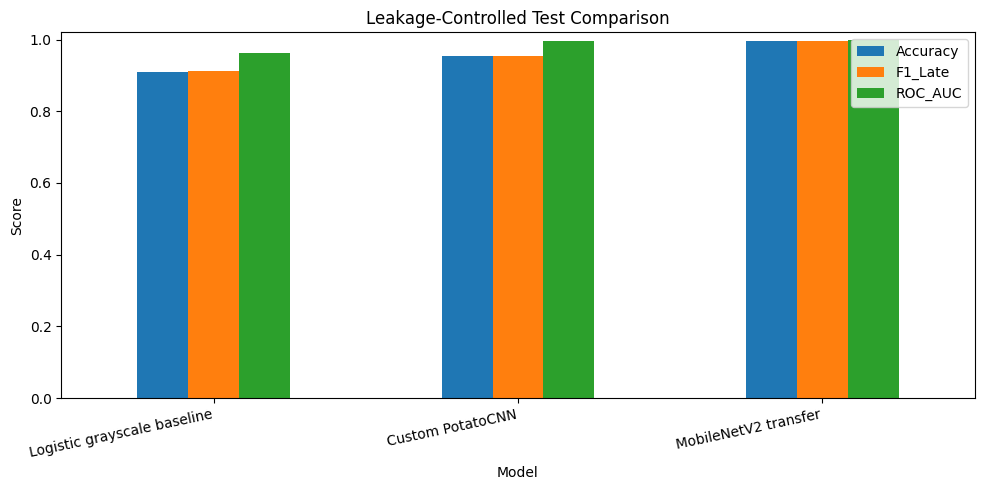

,Model,Accuracy,Precision_Late,Recall_Late,Specificity_Early,F1_Late,Balanced_Accuracy,ROC_AUC,Average_Precision,Threshold,TN,FP,FN,TP
0,Logistic grayscale baseline,0.9100,0.8903,0.9324,0.8882,0.9109,0.9103,0.9624,0.9597,0.70,135,17,10,138
1,Custom PotatoCNN,0.9533,0.9408,0.9662,0.9408,0.9533,0.9535,0.9952,0.9953,0.38,143,9,5,143
2,MobileNetV2 transfer,0.9967,1.0000,0.9932,1.0000,0.9966,0.9966,1.0000,1.0000,0.64,152,0,1,147


,Model_A,Model_B,A_only_correct,B_only_correct,Discordant,Exact_p_value
0,Logistic,Custom,8,21,29,0.0241
1,Logistic,MobileNetV2,1,27,28,0.0000
2,Custom,MobileNetV2,1,14,15,0.0010


In [21]:
# Actual MobileNetV2 transfer-learning comparator
import copy
from torchvision.models import mobilenet_v2,MobileNet_V2_Weights
from scipy.stats import binomtest

mobile_model=mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V2)
for p in mobile_model.features.parameters(): p.requires_grad=False
mobile_model.classifier[1]=nn.Linear(mobile_model.classifier[1].in_features,1)
mobile_model=mobile_model.to(device); mobile_criterion=nn.BCEWithLogitsLoss()
mobile_history=[]; mobile_best_loss=np.inf; mobile_best_state=None

def mobile_epoch(loader,training,optimiser=None):
    mobile_model.train(training); total=0; labels=[]; probabilities=[]
    for x,y in loader:
        x,y=x.to(device),y.to(device)
        if training: optimiser.zero_grad()
        with torch.set_grad_enabled(training):
            logits=mobile_model(x).squeeze(1); loss=mobile_criterion(logits,y)
            if training: loss.backward(); optimiser.step()
        total += loss.item()*x.size(0); labels.extend(y.detach().cpu().numpy())
        probabilities.extend(torch.sigmoid(logits).detach().cpu().numpy())
    labels=np.asarray(labels).astype(int); probabilities=np.asarray(probabilities)
    return total/len(loader.dataset),f1_score(labels,probabilities>=.5,zero_division=0)

global_epoch=0
for phase,epochs,lr in [("head",4,1e-3),("fine_tune",4,1e-4)]:
    if phase=="fine_tune":
        for p in mobile_model.features[-2:].parameters(): p.requires_grad=True
    opt=torch.optim.Adam([p for p in mobile_model.parameters() if p.requires_grad],lr=lr); wait=0
    for _ in range(epochs):
        global_epoch+=1; tr_loss,tr_f1=mobile_epoch(train_loader,True,opt); va_loss,va_f1=mobile_epoch(val_loader,False)
        mobile_history.append([global_epoch,phase,tr_loss,va_loss,tr_f1,va_f1])
        print(f"MobileNet {global_epoch:02d} {phase}: train={tr_loss:.4f} val={va_loss:.4f} val_f1={va_f1:.4f}")
        if va_loss < mobile_best_loss:
            mobile_best_loss=va_loss; mobile_best_state=copy.deepcopy(mobile_model.state_dict()); wait=0
        else:
            wait+=1
            if wait>=3: break
mobile_model.load_state_dict(mobile_best_state); torch.save(mobile_model.state_dict(),MODEL_DIR/"best_mobilenet_v2.pt")
mobile_history_df=pd.DataFrame(mobile_history,columns=["epoch","phase","train_loss","val_loss","train_f1","val_f1"])
mobile_history_df.to_csv(TAB_DIR/"mobilenet_v2_training_history.csv",index=False)
mobile_val_true,mobile_val_prob=torch_probabilities(mobile_model,val_loader)
MOBILE_THRESHOLD=select_f1_threshold(mobile_val_true,mobile_val_prob)
mobile_test_true,mobile_test_prob=torch_probabilities(mobile_model,test_loader)
mobile_test_pred=(mobile_test_prob>=MOBILE_THRESHOLD).astype(int)
mobile_metrics=metric_record(mobile_test_true,mobile_test_prob,MOBILE_THRESHOLD)
pd.DataFrame([{"Model":"MobileNetV2 transfer",**mobile_metrics}]).to_csv(TAB_DIR/"mobilenet_v2_test_metrics.csv",index=False)
pd.DataFrame({"filepath":test_df.filepath,"true_label":mobile_test_true,"late_probability":mobile_test_prob,"prediction":mobile_test_pred}).to_csv(TAB_DIR/"mobilenet_v2_test_predictions.csv",index=False)
model_comparison_df=pd.DataFrame([
    {"Model":"Logistic grayscale baseline",**baseline_metrics},
    {"Model":"Custom PotatoCNN",**custom_metrics},
    {"Model":"MobileNetV2 transfer",**mobile_metrics}])
model_comparison_df.to_csv(TAB_DIR/"final_model_comparison.csv",index=False)
predictions={"Logistic":baseline_test_pred,"Custom":y_pred,"MobileNetV2":mobile_test_pred}; mcnemar=[]
for a,b in [("Logistic","Custom"),("Logistic","MobileNetV2"),("Custom","MobileNetV2")]:
    ca=predictions[a]==y_true; cb=predictions[b]==y_true
    ao=int(np.sum(ca&~cb)); bo=int(np.sum(~ca&cb)); n=ao+bo
    p=1.0 if n==0 else binomtest(min(ao,bo),n,.5).pvalue
    mcnemar.append([a,b,ao,bo,n,p])
mcnemar_df=pd.DataFrame(mcnemar,columns=["Model_A","Model_B","A_only_correct","B_only_correct","Discordant","Exact_p_value"])
mcnemar_df.to_csv(TAB_DIR/"model_mcnemar_tests.csv",index=False)
ax=model_comparison_df.set_index("Model")[["Accuracy","F1_Late","ROC_AUC"]].plot(kind="bar",figsize=(10,5))
ax.set_ylim(0,1.02); ax.set_ylabel("Score"); ax.set_title("Leakage-Controlled Test Comparison")
plt.xticks(rotation=12,ha="right"); plt.tight_layout(); plt.savefig(FIG_DIR/"final_model_comparison.png",dpi=300,bbox_inches="tight"); plt.show()
display(model_comparison_df.round(4)); display(mcnemar_df.round(4))


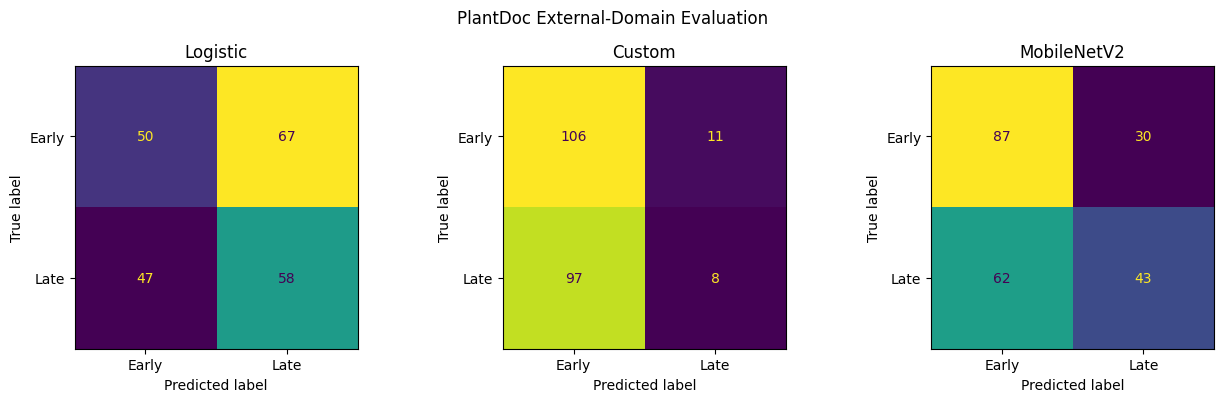

,Model,Accuracy,Precision_Late,Recall_Late,Specificity_Early,F1_Late,Balanced_Accuracy,ROC_AUC,Average_Precision,Threshold,TN,FP,FN,TP
0,Logistic grayscale baseline,0.4865,0.4640,0.5524,0.4274,0.5043,0.4899,0.5044,0.4903,0.70,50,67,47,58
1,Custom PotatoCNN,0.5135,0.4211,0.0762,0.9060,0.1290,0.4911,0.5361,0.4901,0.38,106,11,97,8
2,MobileNetV2 transfer,0.5856,0.5890,0.4095,0.7436,0.4831,0.5766,0.6210,0.5554,0.64,87,30,62,43


,PlantDoc_images,Exact_MD5_overlap,PlantDoc_images_with_dHash_distance_le_4,Use
0,222,0,0,External stress test only; never fit/tune


PlantDoc is small and internet-scraped: useful domain-shift evidence, not a field trial.


In [22]:
# Independent external-domain evaluation: PlantDoc potato subset
external_rows=[]
for relative,label in [("train/Potato leaf early blight",0),("train/Potato leaf late blight",1),
                       ("test/Potato leaf early blight",0),("test/Potato leaf late blight",1)]:
    for path in sorted((PLANTDOC_DIR/relative).iterdir()):
        if path.suffix.lower() in VALID_EXTENSIONS: external_rows.append([str(path),relative,label])
external_df=pd.DataFrame(external_rows,columns=["filepath","source_folder","label"])
external_df["class_name"]=external_df.label.map({0:"Early Blight",1:"Late Blight"})
external_loader=DataLoader(PotatoDataset(external_df,eval_tfms),batch_size=BATCH,shuffle=False)
external_true,custom_external_prob=torch_probabilities(model,external_loader)
_,mobile_external_prob=torch_probabilities(mobile_model,external_loader)
baseline_external_prob=baseline_model.predict_proba(grayscale_features(external_df))[:,1]
external_results=[]; external_predictions=external_df.copy()
for name,probability,threshold in [("Logistic grayscale baseline",baseline_external_prob,BASELINE_THRESHOLD),
        ("Custom PotatoCNN",custom_external_prob,CUSTOM_THRESHOLD),("MobileNetV2 transfer",mobile_external_prob,MOBILE_THRESHOLD)]:
    external_results.append({"Model":name,**metric_record(external_true,probability,threshold)})
    key=name.lower().replace(" ","_")
    external_predictions[key+"_probability"]=probability; external_predictions[key+"_prediction"]=(probability>=threshold).astype(int)
external_results_df=pd.DataFrame(external_results)
external_results_df.to_csv(TAB_DIR/"plantdoc_external_metrics.csv",index=False)
external_predictions.to_csv(TAB_DIR/"plantdoc_external_predictions.csv",index=False)
primary_md5={md5(p) for p in potato_df.filepath}; external_md5={md5(p) for p in external_df.filepath}
primary_dhash=[dhash(p) for p in potato_df.filepath]; external_dhash=[dhash(p) for p in external_df.filepath]
external_audit_df=pd.DataFrame([{"PlantDoc_images":len(external_df),"Exact_MD5_overlap":len(primary_md5&external_md5),
    "PlantDoc_images_with_dHash_distance_le_4":sum(min((h ^ p).bit_count() for p in primary_dhash)<=4 for h in external_dhash),
    "Use":"External stress test only; never fit/tune"}])
external_audit_df.to_csv(TAB_DIR/"plantdoc_external_overlap_audit.csv",index=False)
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,(name,probability,threshold) in zip(axes,[("Logistic",baseline_external_prob,BASELINE_THRESHOLD),("Custom",custom_external_prob,CUSTOM_THRESHOLD),("MobileNetV2",mobile_external_prob,MOBILE_THRESHOLD)]):
    ConfusionMatrixDisplay.from_predictions(external_true,probability>=threshold,display_labels=["Early","Late"],colorbar=False,ax=ax); ax.set_title(name)
plt.suptitle("PlantDoc External-Domain Evaluation"); plt.tight_layout(); plt.savefig(FIG_DIR/"plantdoc_external_confusion_matrices.png",dpi=300,bbox_inches="tight"); plt.show()
display(external_results_df.round(4)); display(external_audit_df)
print("PlantDoc is small and internet-scraped: useful domain-shift evidence, not a field trial.")


In [23]:
# Responsible prediction-interface prototype (launch is optional)
def predict_responsibly(image):
    if image is None: return {"Early Blight":0.0,"Late Blight":0.0},"Please provide an image."
    x=eval_tfms(image.convert("RGB")).unsqueeze(0).to(device); model.eval()
    with torch.no_grad(): p_late=float(torch.sigmoid(model(x)).item())
    probabilities={"Early Blight":1-p_late,"Late Blight":p_late}; confidence=max(probabilities.values())
    flag="LOW CONFIDENCE — expert review required. " if confidence<.75 else ""
    warning=flag+"Proof-of-concept only: no Healthy/Other class, no diagnosis, and no treatment advice. Confirm professionally."
    return probabilities,warning

LAUNCH_DEMO=False
if LAUNCH_DEMO:
    try: import gradio as gr
    except ImportError:
        subprocess.run([sys.executable,"-m","pip","install","-q","gradio"],check=True); import gradio as gr
    gr.Interface(predict_responsibly,gr.Image(type="pil"),[gr.Label(),gr.Textbox()],title="Potato Blight Decision-Support Prototype").launch(share=True,prevent_thread_lock=True)
else: print("Set LAUNCH_DEMO=True and rerun this cell to launch the temporary Colab interface.")


Set LAUNCH_DEMO=True and rerun this cell to launch the temporary Colab interface.


In [24]:
# CELL 17R: Robustness testing under image perturbations

from torchvision.transforms import functional as TF
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np, pandas as pd, torch
from PIL import Image, ImageFilter

def perturb(img, mode):
    if mode == "Dark":       return TF.adjust_brightness(img, 0.6)
    if mode == "Bright":     return TF.adjust_brightness(img, 1.4)
    if mode == "Contrast":   return TF.adjust_contrast(img, 0.6)
    if mode == "Blur":       return img.filter(ImageFilter.GaussianBlur(2))
    if mode == "Rotation":   return TF.rotate(img, 20)
    if mode == "Noise":
        x = TF.to_tensor(img)
        x = torch.clamp(x + 0.08*torch.randn_like(x), 0, 1)
        return TF.to_pil_image(x)
    return img

conditions = ["Original", "Dark", "Bright", "Contrast", "Blur", "Rotation", "Noise"]
rows = []

model.eval()

for condition in conditions:
    yt, yp = [], []

    with torch.no_grad():
        for _, r in test_df.iterrows():
            img = Image.open(r.filepath).convert("RGB")
            img = perturb(img, condition)

            x = eval_tfms(img).unsqueeze(0).to(device)
            yp.append(torch.sigmoid(model(x)).item())
            yt.append(int(r.label))

    yt, yp = np.array(yt), np.array(yp)
    pred = (yp >= CUSTOM_THRESHOLD).astype(int)

    rows.append([
        condition,
        accuracy_score(yt, pred),
        f1_score(yt, pred),
        roc_auc_score(yt, yp)
    ])

robust_df = pd.DataFrame(rows, columns=["Condition","Accuracy","F1","ROC_AUC"])
robust_df.to_csv(TAB_DIR / "robustness_results.csv", index=False)

display(robust_df.round(4))

print("\n=== CELL 17R SUMMARY ===")
for _, r in robust_df.iterrows():
    print(f"{r.Condition:<10} | Acc={r.Accuracy:.4f} | F1={r.F1:.4f} | AUC={r.ROC_AUC:.4f}")
print(f"Table saved : {TAB_DIR / 'robustness_results.csv'}")

,Condition,Accuracy,F1,ROC_AUC
0,Original,0.9533,0.9533,0.9952
1,Dark,0.4933,0.6607,0.4951
2,Bright,0.7000,0.5631,0.9761
3,Contrast,0.8633,0.8783,0.9924
4,Blur,0.8733,0.8862,0.9884
5,Rotation,0.9500,0.9492,0.9947
6,Noise,0.9500,0.9492,0.9934



=== CELL 17R SUMMARY ===
Original   | Acc=0.9533 | F1=0.9533 | AUC=0.9952
Dark       | Acc=0.4933 | F1=0.6607 | AUC=0.4951
Bright     | Acc=0.7000 | F1=0.5631 | AUC=0.9761
Contrast   | Acc=0.8633 | F1=0.8783 | AUC=0.9924
Blur       | Acc=0.8733 | F1=0.8862 | AUC=0.9884
Rotation   | Acc=0.9500 | F1=0.9492 | AUC=0.9947
Noise      | Acc=0.9500 | F1=0.9492 | AUC=0.9934
Table saved : /content/PlantVillage-Dataset/raw/outputs/tables/robustness_results.csv


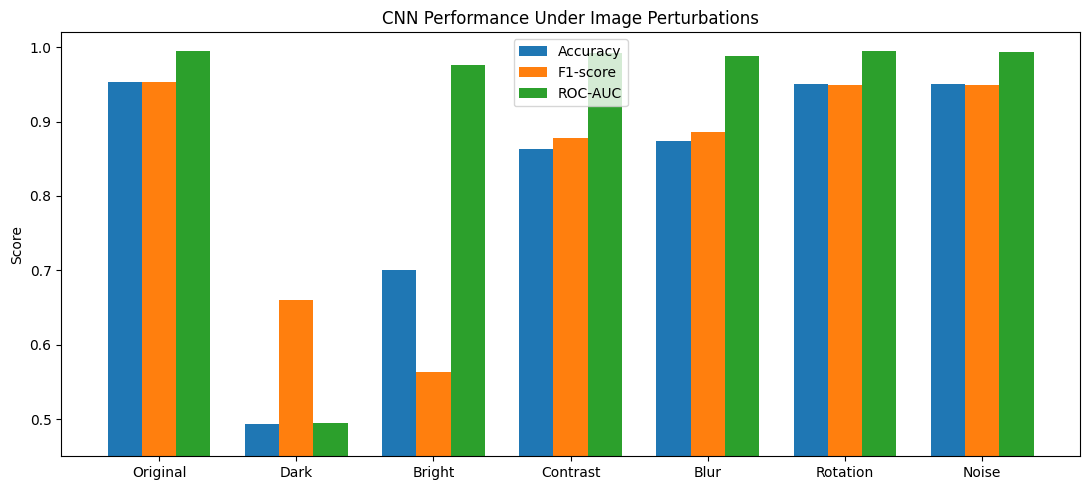

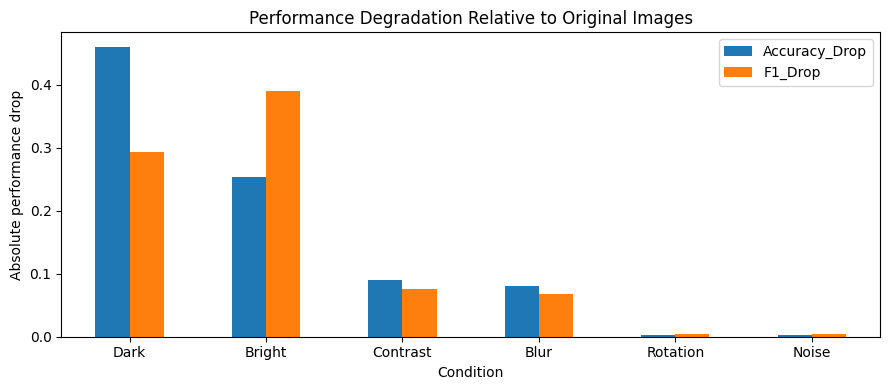

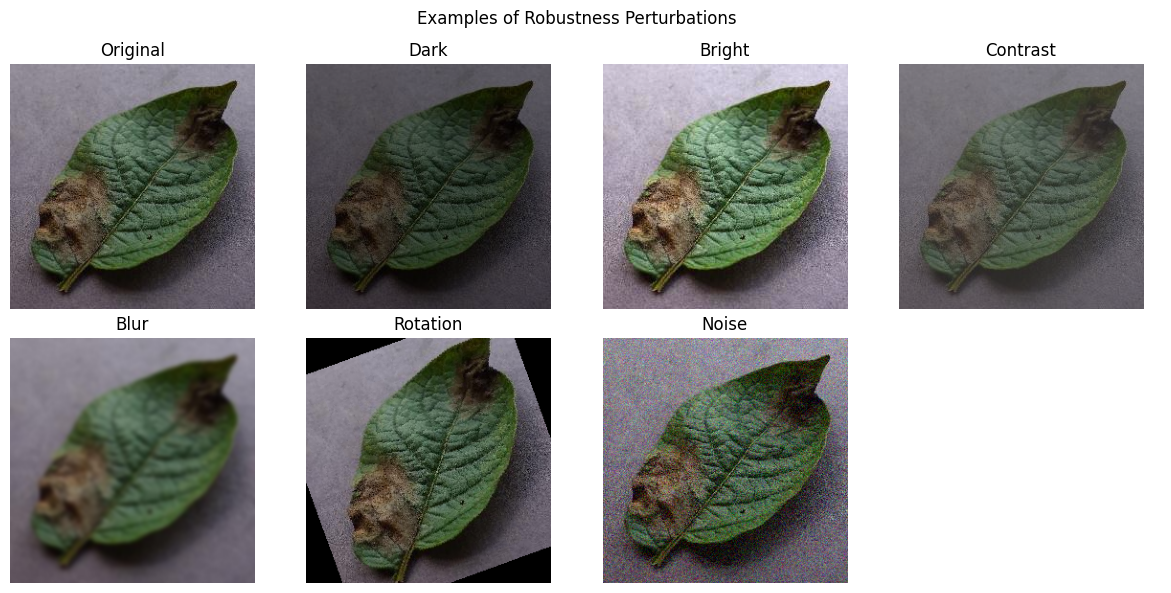


=== CELL 18 SUMMARY ===
Robustness conditions : Original, Dark, Bright, Contrast, Blur, Rotation, Noise
Worst Accuracy        : Dark (0.4933)
Worst F1              : Bright (0.5631)
Best robustness       : Rotation
Figures saved         : /content/PlantVillage-Dataset/raw/outputs/figures
Drop table saved      : /content/PlantVillage-Dataset/raw/outputs/tables/robustness_performance_drop.csv


In [25]:
# CELL 18: Visualise robustness results

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. Metric comparison
x = np.arange(len(robust_df))
w = 0.25

plt.figure(figsize=(11,5))
plt.bar(x-w, robust_df.Accuracy, w, label="Accuracy")
plt.bar(x,   robust_df.F1,       w, label="F1-score")
plt.bar(x+w, robust_df.ROC_AUC,  w, label="ROC-AUC")
plt.xticks(x, robust_df.Condition)
plt.ylim(0.45, 1.02)
plt.ylabel("Score")
plt.title("CNN Performance Under Image Perturbations")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"robustness_metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Performance degradation from original
baseline = robust_df.iloc[0]
drop_df = robust_df.copy()
drop_df["Accuracy_Drop"] = baseline.Accuracy - drop_df.Accuracy
drop_df["F1_Drop"] = baseline.F1 - drop_df.F1

drop_df.iloc[1:].plot(
    x="Condition", y=["Accuracy_Drop","F1_Drop"],
    kind="bar", figsize=(9,4)
)
plt.ylabel("Absolute performance drop")
plt.title("Performance Degradation Relative to Original Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR/"robustness_performance_drop.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Example of every perturbation
sample_path = test_df.sample(1, random_state=42).iloc[0].filepath
original = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(12,6))

for ax, condition in zip(axes.flat, conditions):
    img = perturb(original.copy(), condition)
    ax.imshow(img)
    ax.set_title(condition)
    ax.axis("off")

axes.flat[-1].axis("off")
plt.suptitle("Examples of Robustness Perturbations")
plt.tight_layout()
plt.savefig(FIG_DIR/"robustness_perturbation_examples.png", dpi=300, bbox_inches="tight")
plt.show()

drop_df.to_csv(TAB_DIR/"robustness_performance_drop.csv", index=False)

print("\n=== CELL 18 SUMMARY ===")
print("Robustness conditions :", ", ".join(conditions))
print(f"Worst Accuracy        : {robust_df.loc[robust_df.Accuracy.idxmin(),'Condition']} "
      f"({robust_df.Accuracy.min():.4f})")
print(f"Worst F1              : {robust_df.loc[robust_df.F1.idxmin(),'Condition']} "
      f"({robust_df.F1.min():.4f})")
print(f"Best robustness       : {robust_df.iloc[1:].loc[robust_df.iloc[1:].F1.idxmax(),'Condition']}")
print(f"Figures saved         : {FIG_DIR}")
print(f"Drop table saved      : {TAB_DIR/'robustness_performance_drop.csv'}")

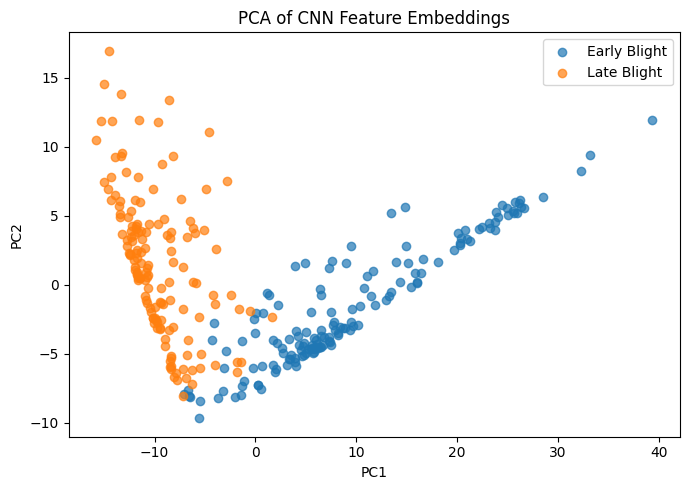

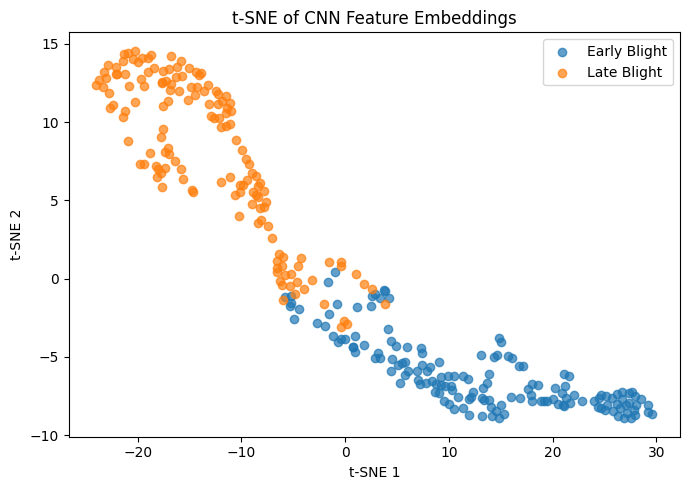


=== CELL 19 SUMMARY ===
Test embeddings       : 300
Feature dimensions    : 128
PCA variance explained: 0.9966
PCA figure            : /content/PlantVillage-Dataset/raw/outputs/figures/feature_pca.png
t-SNE figure          : /content/PlantVillage-Dataset/raw/outputs/figures/feature_tsne.png
Embeddings saved      : /content/PlantVillage-Dataset/raw/outputs/tables/feature_embeddings.csv


In [26]:
# CELL 19: PCA + t-SNE feature-space visualisation

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch.nn.functional as F

features, labels = [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        z = model.features(x.to(device))
        z = F.adaptive_avg_pool2d(z, 1).flatten(1)
        features.append(z.cpu().numpy())
        labels.extend(y.numpy())

features = np.vstack(features)
labels = np.array(labels).astype(int)

# PCA
pca = PCA(n_components=2)
pca_xy = pca.fit_transform(features)

# t-SNE
tsne_xy = TSNE(
    n_components=2, perplexity=30,
    random_state=42, init="pca", learning_rate="auto"
).fit_transform(features)

names = ["Early Blight", "Late Blight"]

# Save embeddings
embed_df = pd.DataFrame({
    "label": labels,
    "class": [names[i] for i in labels],
    "PCA1": pca_xy[:,0], "PCA2": pca_xy[:,1],
    "TSNE1": tsne_xy[:,0], "TSNE2": tsne_xy[:,1]
})
embed_df.to_csv(TAB_DIR/"feature_embeddings.csv", index=False)

# PCA figure
plt.figure(figsize=(7,5))
for i, name in enumerate(names):
    m = labels == i
    plt.scatter(pca_xy[m,0], pca_xy[m,1], label=name, alpha=.7)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA of CNN Feature Embeddings")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"feature_pca.png", dpi=300, bbox_inches="tight")
plt.show()

# t-SNE figure
plt.figure(figsize=(7,5))
for i, name in enumerate(names):
    m = labels == i
    plt.scatter(tsne_xy[m,0], tsne_xy[m,1], label=name, alpha=.7)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("t-SNE of CNN Feature Embeddings")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"feature_tsne.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== CELL 19 SUMMARY ===")
print(f"Test embeddings       : {len(features)}")
print(f"Feature dimensions    : {features.shape[1]}")
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA figure            : {FIG_DIR/'feature_pca.png'}")
print(f"t-SNE figure          : {FIG_DIR/'feature_tsne.png'}")
print(f"Embeddings saved      : {TAB_DIR/'feature_embeddings.csv'}")

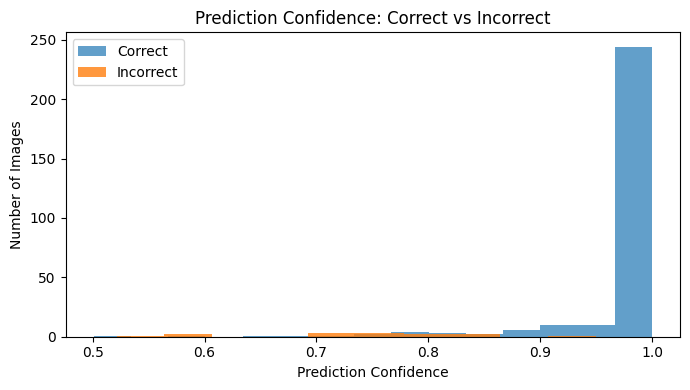

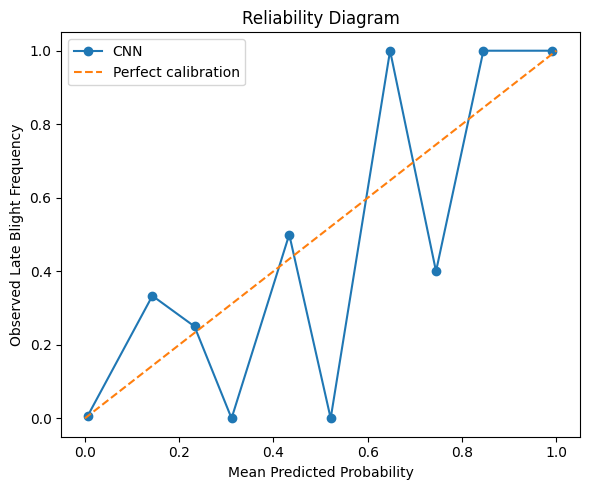

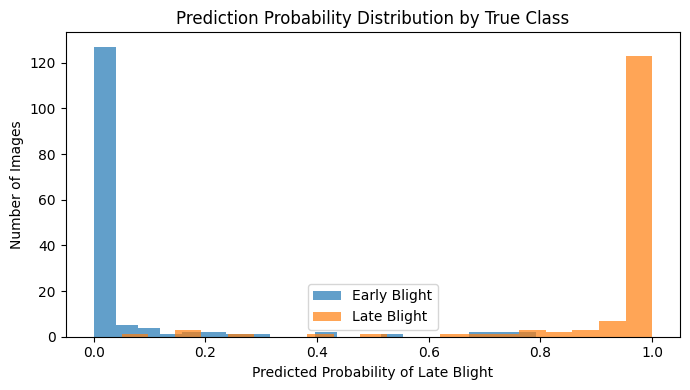


=== CELL 20 SUMMARY ===
Mean confidence       : 0.9652
Correct mean conf.    : 0.9764
Incorrect mean conf.  : 0.7371
Minimum confidence    : 0.5008
Brier score           : 0.0299
Incorrect predictions : 14
Figures saved         : /content/PlantVillage-Dataset/raw/outputs/figures
Calibration table     : /content/PlantVillage-Dataset/raw/outputs/tables/calibration_curve.csv


In [27]:
# CELL 20: Confidence + calibration + uncertainty visualisation

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np
import matplotlib.pyplot as plt

confidence = np.maximum(y_prob, 1 - y_prob)
correct = y_pred == y_true

# 1. Confidence distribution
plt.figure(figsize=(7,4))
plt.hist(confidence[correct], bins=15, alpha=.7, label="Correct")
plt.hist(confidence[~correct], bins=10, alpha=.8, label="Incorrect")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")
plt.title("Prediction Confidence: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"confidence_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Reliability / calibration curve
frac_pos, mean_pred = calibration_curve(
    y_true, y_prob, n_bins=10, strategy="uniform"
)

plt.figure(figsize=(6,5))
plt.plot(mean_pred, frac_pos, marker="o", label="CNN")
plt.plot([0,1], [0,1], "--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Late Blight Frequency")
plt.title("Reliability Diagram")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"reliability_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Probability distribution by true class
plt.figure(figsize=(7,4))
plt.hist(y_prob[y_true==0], bins=20, alpha=.7, label="Early Blight")
plt.hist(y_prob[y_true==1], bins=20, alpha=.7, label="Late Blight")
plt.xlabel("Predicted Probability of Late Blight")
plt.ylabel("Number of Images")
plt.title("Prediction Probability Distribution by True Class")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"probability_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

brier = brier_score_loss(y_true, y_prob)

calibration_df = pd.DataFrame({
    "Mean_Predicted_Probability": mean_pred,
    "Observed_Frequency": frac_pos
})
calibration_df.to_csv(TAB_DIR/"calibration_curve.csv", index=False)

print("\n=== CELL 20 SUMMARY ===")
print(f"Mean confidence       : {confidence.mean():.4f}")
print(f"Correct mean conf.    : {confidence[correct].mean():.4f}")
print(f"Incorrect mean conf.  : {confidence[~correct].mean():.4f}")
print(f"Minimum confidence    : {confidence.min():.4f}")
print(f"Brier score           : {brier:.4f}")
print(f"Incorrect predictions : {(~correct).sum()}")
print(f"Figures saved         : {FIG_DIR}")
print(f"Calibration table     : {TAB_DIR/'calibration_curve.csv'}")

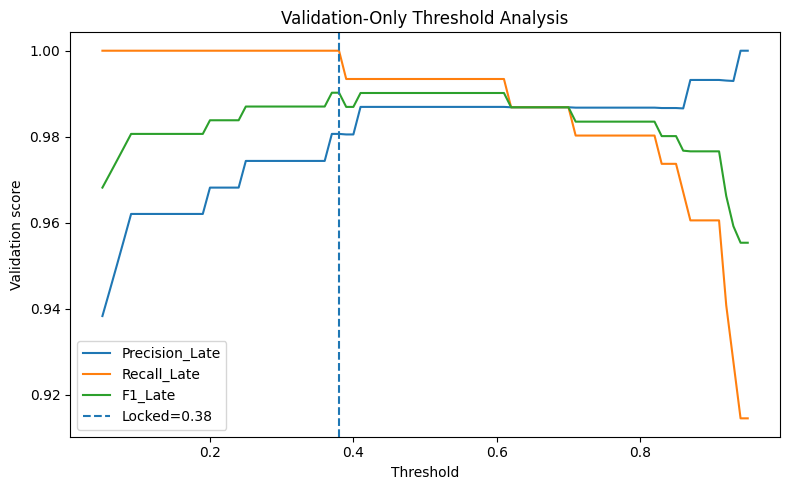

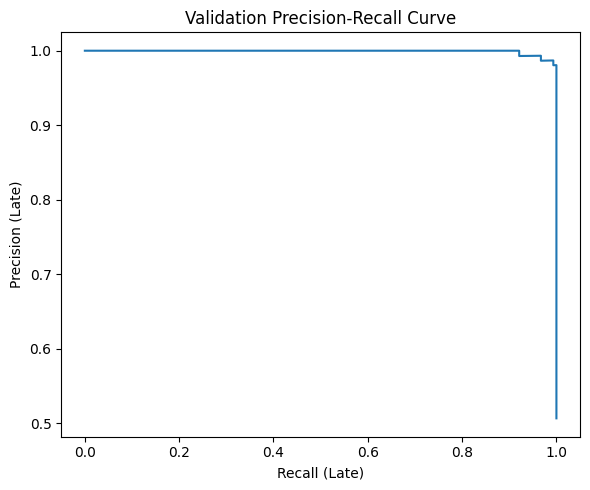

In [28]:
# CELL 21: Validation-only threshold and precision-recall analysis
from sklearn.metrics import precision_recall_curve
thresholds=np.arange(.05,.96,.01); rows=[]
for threshold in thresholds:
    prediction=val_prob_custom>=threshold
    rows.append([threshold,precision_score(val_true_custom,prediction,zero_division=0),recall_score(val_true_custom,prediction,zero_division=0),f1_score(val_true_custom,prediction,zero_division=0)])
thr_df=pd.DataFrame(rows,columns=["Threshold","Precision_Late","Recall_Late","F1_Late"])
thr_df.to_csv(TAB_DIR/"threshold_analysis.csv",index=False)
plt.figure(figsize=(8,5))
for metric in thr_df.columns[1:]: plt.plot(thr_df.Threshold,thr_df[metric],label=metric)
plt.axvline(CUSTOM_THRESHOLD,linestyle="--",label=f"Locked={CUSTOM_THRESHOLD:.2f}"); plt.xlabel("Threshold"); plt.ylabel("Validation score"); plt.title("Validation-Only Threshold Analysis"); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR/"threshold_analysis.png",dpi=300,bbox_inches="tight"); plt.show()
pr_p,pr_r,_=precision_recall_curve(val_true_custom,val_prob_custom); plt.figure(figsize=(6,5)); plt.plot(pr_r,pr_p)
plt.xlabel("Recall (Late)"); plt.ylabel("Precision (Late)"); plt.title("Validation Precision-Recall Curve"); plt.tight_layout(); plt.savefig(FIG_DIR/"precision_recall_curve.png",dpi=300,bbox_inches="tight"); plt.show()


In [29]:
# CELL 22: Pre-specified versus validation-locked threshold on test
pred_05=y_prob>=.5
threshold_result=pd.DataFrame([
    [.5,"Pre-specified",accuracy_score(y_true,pred_05),precision_score(y_true,pred_05),recall_score(y_true,pred_05),f1_score(y_true,pred_05)],
    [CUSTOM_THRESHOLD,"Validation-selected",accuracy_score(y_true,y_pred),precision_score(y_true,y_pred),recall_score(y_true,y_pred),f1_score(y_true,y_pred)]],
    columns=["Threshold","Source","Accuracy","Precision_Late","Recall_Late","F1_Late"])
threshold_result.to_csv(TAB_DIR/"validation_threshold_comparison.csv",index=False); display(threshold_result.round(4))
print("Test labels were not used to choose either threshold.")


,Threshold,Source,Accuracy,Precision_Late,Recall_Late,F1_Late
0,0.50,Pre-specified,0.9533,0.9527,0.9527,0.9527
1,0.38,Validation-selected,0.9533,0.9408,0.9662,0.9533


Test labels were not used to choose either threshold.


,Configuration,Accuracy,F1,Epochs
0,No Aug + No Dropout,0.9967,0.9967,15
1,Aug + No Dropout,0.9933,0.9935,14
2,No Aug + Dropout,0.9933,0.9935,15
3,Aug + Dropout,0.9933,0.9935,14


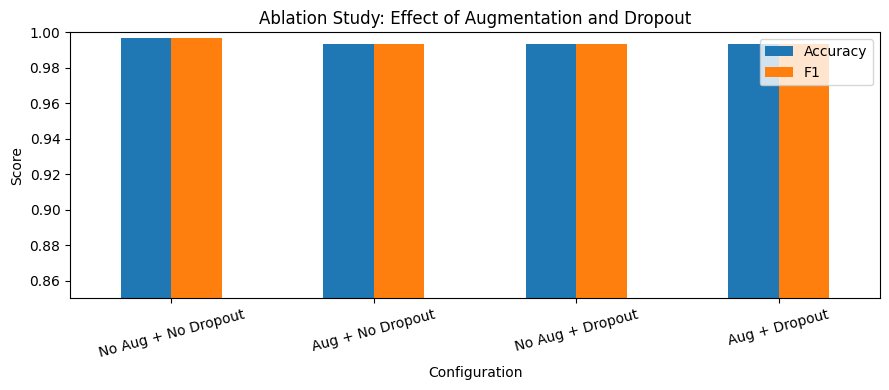


=== CELL 23 SUMMARY ===
No Aug + No Dropout   | Acc=0.9967 | F1=0.9967
Aug + No Dropout      | Acc=0.9933 | F1=0.9935
No Aug + Dropout      | Acc=0.9933 | F1=0.9935
Aug + Dropout         | Acc=0.9933 | F1=0.9935
Best configuration : No Aug + No Dropout
Best F1            : 0.9967
Figure saved       : /content/PlantVillage-Dataset/raw/outputs/figures/ablation_comparison.png
Table saved        : /content/PlantVillage-Dataset/raw/outputs/tables/ablation_results.csv


In [30]:
# CELL 23: Validation-only ablation study

import random, time
from sklearn.metrics import accuracy_score, f1_score

# Non-augmented training loader
plain_set = PotatoDataset(train_df, eval_tfms)
plain_loader = DataLoader(plain_set, batch_size=BATCH, shuffle=True)

class AblationCNN(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3 if dropout else 0),
            nn.Linear(128,1)
        )
    def forward(self,x):
        return self.classifier(self.features(x)).squeeze(1)

variants = {
    "No Aug + No Dropout": (plain_loader, False),
    "Aug + No Dropout":    (train_loader, False),
    "No Aug + Dropout":    (plain_loader, True),
    "Aug + Dropout":       (train_loader, True)
}

ablation_rows = []

for name, (loader, use_drop) in variants.items():
    torch.manual_seed(42)
    m = AblationCNN(use_drop).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    best_loss, best_state, wait = 1e9, None, 0

    for ep in range(15):
        m.train()
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = criterion(m(x), y)
            loss.backward(); opt.step()

        m.eval()
        vloss = 0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                vloss += criterion(m(x),y).item()*x.size(0)
        vloss /= len(val_set)

        if vloss < best_loss:
            best_loss, wait = vloss, 0
            best_state = copy.deepcopy(m.state_dict())
        else:
            wait += 1
            if wait >= 3: break

    m.load_state_dict(best_state)

    yt, yp = [], []
    with torch.no_grad():
        for x,y in val_loader:
            p = torch.sigmoid(m(x.to(device)))
            yt.extend(y.numpy()); yp.extend((p>=0.5).cpu().numpy())

    ablation_rows.append([
        name, accuracy_score(yt,yp), f1_score(yt,yp), ep+1
    ])

ablation_df = pd.DataFrame(
    ablation_rows,
    columns=["Configuration","Accuracy","F1","Epochs"]
)
ablation_df.to_csv(TAB_DIR/"ablation_results.csv", index=False)
display(ablation_df.round(4))

# Report figure
ablation_df.set_index("Configuration")[["Accuracy","F1"]].plot(
    kind="bar", figsize=(9,4)
)
plt.ylim(0.85,1.0)
plt.ylabel("Score")
plt.title("Ablation Study: Effect of Augmentation and Dropout")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR/"ablation_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

best = ablation_df.loc[ablation_df.F1.idxmax()]

print("\n=== CELL 23 SUMMARY ===")
for _,r in ablation_df.iterrows():
    print(f"{r.Configuration:<21} | Acc={r.Accuracy:.4f} | F1={r.F1:.4f}")
print(f"Best configuration : {best.Configuration}")
print(f"Best F1            : {best.F1:.4f}")
print(f"Figure saved       : {FIG_DIR/'ablation_comparison.png'}")
print(f"Table saved        : {TAB_DIR/'ablation_results.csv'}")

,Metric,Value
0,Total parameters,93377.000
1,Trainable parameters,93377.000
2,Model size (MB),0.360
3,Inference latency (ms),0.819
4,Throughput (images/sec),1221.616


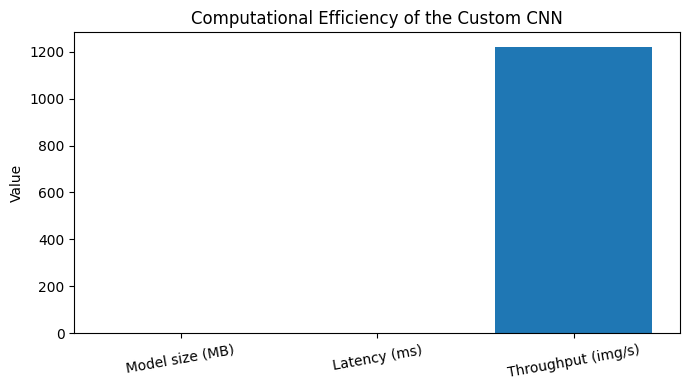


=== CELL 24 SUMMARY ===
Parameters       : 93,377
Model size       : 0.360 MB
Mean latency     : 0.819 ms/image
Throughput       : 1221.6 images/sec
Device           : cuda
Figure saved     : /content/PlantVillage-Dataset/raw/outputs/figures/model_efficiency.png
Table saved      : /content/PlantVillage-Dataset/raw/outputs/tables/model_efficiency.csv


In [31]:
# CELL 24: Computational efficiency analysis

import time, os
import pandas as pd
import matplotlib.pyplot as plt

model.eval()

# Parameter counts
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Saved model size
model_path = MODEL_DIR / "best_potato_cnn.pt"
size_mb = os.path.getsize(model_path) / (1024**2)

# Warm-up
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    for _ in range(20):
        _ = model(dummy)

if device.type == "cuda":
    torch.cuda.synchronize()

# Single-image inference latency
times = []
with torch.no_grad():
    for _ in range(100):
        start = time.perf_counter()
        _ = model(dummy)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append((time.perf_counter() - start) * 1000)

latency = sum(times) / len(times)
throughput = 1000 / latency

eff_df = pd.DataFrame({
    "Metric": ["Total parameters", "Trainable parameters",
               "Model size (MB)", "Inference latency (ms)",
               "Throughput (images/sec)"],
    "Value": [total_params, trainable_params,
              size_mb, latency, throughput]
})

eff_df.to_csv(TAB_DIR/"model_efficiency.csv", index=False)
display(eff_df.round(3))

# Report-ready efficiency figure
plot_df = pd.DataFrame({
    "Metric": ["Model size (MB)", "Latency (ms)", "Throughput (img/s)"],
    "Value": [size_mb, latency, throughput]
})

plt.figure(figsize=(7,4))
plt.bar(plot_df.Metric, plot_df.Value)
plt.title("Computational Efficiency of the Custom CNN")
plt.ylabel("Value")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(FIG_DIR/"model_efficiency.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== CELL 24 SUMMARY ===")
print(f"Parameters       : {total_params:,}")
print(f"Model size       : {size_mb:.3f} MB")
print(f"Mean latency     : {latency:.3f} ms/image")
print(f"Throughput       : {throughput:.1f} images/sec")
print(f"Device           : {device}")
print(f"Figure saved     : {FIG_DIR/'model_efficiency.png'}")
print(f"Table saved      : {TAB_DIR/'model_efficiency.csv'}")

,Experiment,Accuracy,F1,ROC_AUC
0,Original Test,0.9533,0.9533,0.9952
1,Segmented Test,0.8800,0.8784,0.9566
2,Dark,0.4933,0.6607,0.4951
3,Bright,0.7000,0.5631,0.9761
4,Contrast,0.8633,0.8783,0.9924
5,Blur,0.8733,0.8862,0.9884
6,Rotation,0.9500,0.9492,0.9947
7,Noise,0.9500,0.9492,0.9934


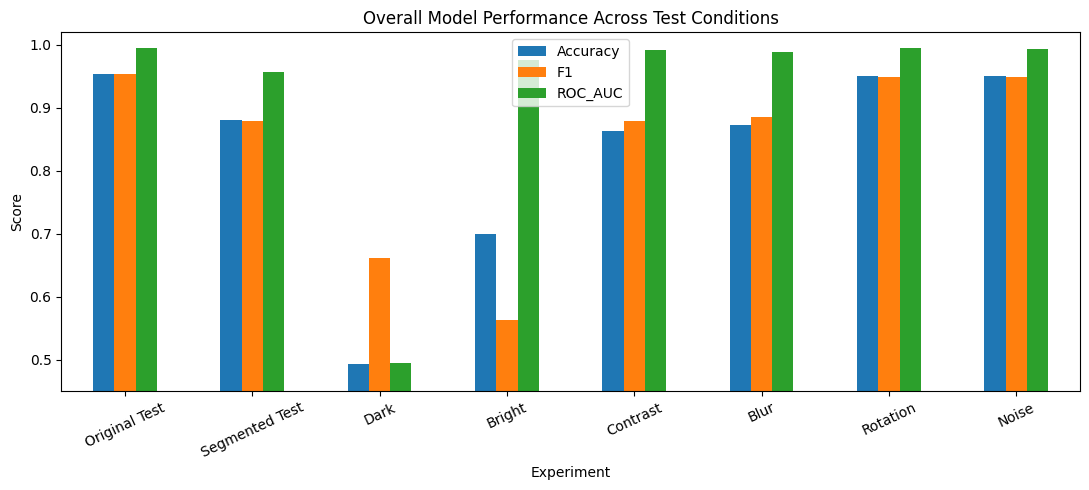

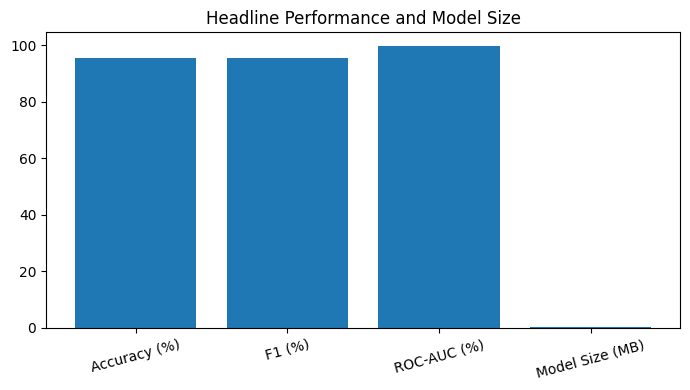


=== CELL 25 SUMMARY ===
Primary accuracy : 0.9533
Primary F1       : 0.9533
Primary ROC-AUC  : 0.9952
Segmented F1     : 0.8784
Worst robustness : Bright
Model size       : 0.360 MB
Figures saved    : /content/PlantVillage-Dataset/raw/outputs/figures
Table saved      : /content/PlantVillage-Dataset/raw/outputs/tables/overall_performance_summary.csv


In [32]:
# CELL 25: Consolidated summary figures and tables

import pandas as pd
import matplotlib.pyplot as plt

# Main comparison table
summary_df = pd.DataFrame({
    "Experiment": [
        "Original Test",
        "Segmented Test",
        "Dark",
        "Bright",
        "Contrast",
        "Blur",
        "Rotation",
        "Noise"
    ],
    "Accuracy": [
        acc,
        cal_metrics.Value[0],
        *robust_df.loc[robust_df.Condition!="Original","Accuracy"].values
    ],
    "F1": [
        f1,
        cal_metrics.Value[3],
        *robust_df.loc[robust_df.Condition!="Original","F1"].values
    ],
    "ROC_AUC": [
        auc,
        cal_metrics.Value[4],
        *robust_df.loc[robust_df.Condition!="Original","ROC_AUC"].values
    ]
})

summary_df.to_csv(TAB_DIR/"overall_performance_summary.csv", index=False)
display(summary_df.round(4))

# Figure: overall performance comparison
summary_df.set_index("Experiment")[["Accuracy","F1","ROC_AUC"]].plot(
    kind="bar", figsize=(11,5)
)

plt.ylim(0.45,1.02)
plt.ylabel("Score")
plt.title("Overall Model Performance Across Test Conditions")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR/"overall_performance_summary.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Figure: headline model characteristics
headline = pd.DataFrame({
    "Metric": ["Accuracy (%)", "F1 (%)", "ROC-AUC (%)", "Model Size (MB)"],
    "Value": [acc*100, f1*100, auc*100, size_mb]
})

plt.figure(figsize=(7,4))
plt.bar(headline.Metric, headline.Value)
plt.title("Headline Performance and Model Size")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR/"headline_model_summary.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("\n=== CELL 25 SUMMARY ===")
print(f"Primary accuracy : {acc:.4f}")
print(f"Primary F1       : {f1:.4f}")
print(f"Primary ROC-AUC  : {auc:.4f}")
print(f"Segmented F1     : {cal_metrics.Value[3]:.4f}")
print(f"Worst robustness : {robust_df.loc[robust_df.F1.idxmin(),'Condition']}")
print(f"Model size       : {size_mb:.3f} MB")
print(f"Figures saved    : {FIG_DIR}")
print(f"Table saved      : {TAB_DIR/'overall_performance_summary.csv'}")

In [33]:
# Final feedback evidence, risks, limitations, and dynamic summary
DOC_DIR=OUT/"documentation"; DOC_DIR.mkdir(parents=True,exist_ok=True)
risk_register_df=pd.DataFrame([
    ["Leaf/data leakage","High","High","Official group split before augmentation; hash audits","Data owner + reviewer"],
    ["Incorrect labels","High","Medium","Inspect errors using authoritative agricultural references; record corrections","Data reviewer"],
    ["Visual similarity","Medium","High","Error analysis, Grad-CAM, confidence and agronomic consultation","Model reviewer"],
    ["Field domain shift","High","High","PlantDoc test, perturbations, segmentation; no deployment claim","Evaluation owner"],
    ["Overconfidence","High","Medium","Calibration, probabilities, uncertainty flag and human escalation","Safety reviewer"],
    ["Version/data loss","Medium","Medium","Pinned commits, splits, checkpoints, environment and Drive copy","Repository owner"],
    ["Repository inactivity","Medium","Medium","Weekly board review, stale-item escalation, backup owner","Team lead"],
    ["Uneven participation","High","Medium","Named issues/PRs/reviews checked each sprint","Team lead + all"]],
    columns=["Risk","Impact","Likelihood","Mitigation","Accountable_role"])
risk_register_df.to_csv(TAB_DIR/"risk_register.csv",index=False)
feedback_df=pd.DataFrame([
    ["Distinctiveness","Implemented","Baseline + custom + MobileNetV2; XAI; robustness; external test; interface"],
    ["Users/value","Documented","Opening framing section"],["5Vs","Implemented","five_vs_summary.csv"],
    ["Architecture","Documented","End-to-end architecture section"],["Technical detail","Implemented","custom_cnn_configuration.csv"],
    ["Baseline","Implemented","baseline_logistic_test_metrics.csv"],["Leaf leakage","Corrected","leaf_group_overlap_audit.csv"],
    ["Metric semantics","Corrected","Late=positive and FN/FP interpretation"],["Conditional weighting","Implemented","Only if imbalance ratio >1.10"],
    ["Explainability","Implemented","Grad-CAM cells"],["External validation","Limited evidence","PlantDoc external-domain test"],
    ["Interface","Prototype","Probability + uncertainty + warning"],
    ["Provenance/licensing","Documented","Pinned sources, citations and PlantDoc licence; PlantVillage terms flagged for verification"],
    ["Jira/names/contributions","External action required","Must use real team records; not fabricated"]],
    columns=["Feedback_item","Status","Evidence_or_action"])
feedback_df.to_csv(TAB_DIR/"feedback_compliance_matrix.csv",index=False)
governance_template_df=pd.DataFrame([
    ["Dataset acquisition and audit"],["Leaf-group split and preprocessing"],["Custom CNN and baseline"],
    ["Transfer learning"],["Evaluation, XAI and robustness"],["Interface and ethics"],["Report and package"]],
    columns=["Deliverable"])
for column in ["Actual_Owner","Actual_Reviewer","Sprint_Start","Due_Date","Dependency","Testing_Requirement","Definition_of_Done","Jira_Issue_URL","GitHub_PR_or_Commit","Status"]:
    governance_template_df[column]="TEAM MUST COMPLETE"
governance_template_df.to_csv(TAB_DIR/"team_governance_template_REQUIRES_REAL_DATA.csv",index=False)
summary_text=f"""POTATO BLIGHT — FINAL LEAKAGE-CONTROLLED SUMMARY
Primary revision: {PLANTVILLAGE_COMMIT}
External revision: {PLANTDOC_COMMIT}
Labels: Early=0; Late=1 (positive)
Images/leaves: {len(potato_df)}/{potato_df.leaf_group.nunique()}
Train/validation/test: {len(train_df)}/{len(val_df)}/{len(test_df)}
Shared leaf groups: {int(group_overlap_df.Shared_Leaf_Groups.sum())}
Class weighting: {USE_CLASS_WEIGHT}

LEAKAGE-CONTROLLED TEST
{model_comparison_df.round(4).to_string(index=False)}

EXTERNAL PLANTDOC
{external_results_df.round(4).to_string(index=False)}

Interpretation: clean PlantVillage results describe a controlled domain after leaf-group isolation. PlantDoc and perturbations assess domain sensitivity. Neither establishes diagnostic safety or generalisation to farms, devices, cultivars, severities, healthy leaves, or other diseases. Predictions are preliminary decision-support only."""
(DOC_DIR/"project_implementation_summary.txt").write_text(summary_text,encoding="utf-8")
(DOC_DIR/"SYSTEM_ARCHITECTURE.txt").write_text("Pinned sources -> ingestion/audit -> immutable raw data -> group-aware split -> train-only augmentation -> baseline/custom/transfer models -> validation locks -> test/external evaluation -> versioned evidence -> responsible interface.\nProduction extension: authenticated upload API, validation, model registry, encrypted transport, minimal retention, audit logs, drift monitoring and reviewed promotion.\n",encoding="utf-8")
(DOC_DIR/"GOVERNANCE_ACTIONS_REQUIRED.txt").write_text("1. Insert every student's real name/ID.\n2. Add the accessible Jira URL.\n3. Give each deliverable an owner, reviewer, due date, dependency, test and definition of done.\n4. Link Jira to GitHub issues/branches/commits/PRs.\n5. Record approvals, scope changes, blockers and escalation.\n6. Ensure meaningful evidence for every member.\nThese records must not be fabricated.\n",encoding="utf-8")
(DOC_DIR/"SCIENTIFIC_LIMITATIONS.txt").write_text("Binary Early-vs-Late only; no Healthy/Other/Unknown class. PlantVillage is controlled. PlantDoc is small, internet-scraped exploratory evidence. Public labels may contain errors. Grad-CAM is not causal pathology. Do not retune on test. GPU timing is runtime-specific. Do not use as diagnosis or treatment advice.\n",encoding="utf-8")
(DOC_DIR/"DATA_PROVENANCE_AND_LICENSES.txt").write_text(f"PlantVillage source: {PLANTVILLAGE_REPOSITORY}\nPinned commit: {PLANTVILLAGE_COMMIT}\nCitation: Mohanty, Hughes and Salathé (2016), Frontiers in Plant Science, DOI 10.3389/fpls.2016.01419.\nThe pinned PlantVillage repository does not expose an explicit LICENSE file; verify terms with the data owner/institution before redistributing images.\n\nPlantDoc source: {PLANTDOC_REPOSITORY}\nPinned commit: {PLANTDOC_COMMIT}\nLicence stated by its repository: Creative Commons Attribution 4.0 International.\nCitation: Singh et al. (2020), PlantDoc, DOI 10.1145/3371158.3371196.\n",encoding="utf-8")
display(feedback_df); print(summary_text)


,Feedback_item,Status,Evidence_or_action
0,Distinctiveness,Implemented,Baseline + custom + MobileNetV2; XAI; robustne...
1,Users/value,Documented,Opening framing section
2,5Vs,Implemented,five_vs_summary.csv
3,Architecture,Documented,End-to-end architecture section
4,Technical detail,Implemented,custom_cnn_configuration.csv
5,Baseline,Implemented,baseline_logistic_test_metrics.csv
6,Leaf leakage,Corrected,leaf_group_overlap_audit.csv
7,Metric semantics,Corrected,Late=positive and FN/FP interpretation
8,Conditional weighting,Implemented,Only if imbalance ratio >1.10
9,Explainability,Implemented,Grad-CAM cells


POTATO BLIGHT — FINAL LEAKAGE-CONTROLLED SUMMARY
Primary revision: 7f7ecc7e1eaca78107e3affe7cb5abd9427e139a
External revision: 5467f6012d78d1c446145d5f582da6096f852ae8
Labels: Early=0; Late=1 (positive)
Images/leaves: 2000/500
Train/validation/test: 1400/300/300
Shared leaf groups: 0
Class weighting: False

LEAKAGE-CONTROLLED TEST
                      Model  Accuracy  Precision_Late  Recall_Late  Specificity_Early  F1_Late  Balanced_Accuracy  ROC_AUC  Average_Precision  Threshold  TN  FP  FN  TP
Logistic grayscale baseline    0.9100          0.8903       0.9324             0.8882   0.9109             0.9103   0.9624             0.9597       0.70 135  17  10 138
           Custom PotatoCNN    0.9533          0.9408       0.9662             0.9408   0.9533             0.9535   0.9952             0.9953       0.38 143   9   5 143
       MobileNetV2 transfer    0.9967          1.0000       0.9932             1.0000   0.9966             0.9966   1.0000             1.0000       0.64 152   0

In [34]:
# FINAL CELL: Corrected report-ready package
import shutil,zipfile,platform
PACKAGE_DIR=OUT/"Report_Ready_Final"; ZIP_PATH=OUT/"Potato_Blight_Final_Report_Ready.zip"
if PACKAGE_DIR.exists(): shutil.rmtree(PACKAGE_DIR)
for folder in ["figures","tables","models","documentation"]: (PACKAGE_DIR/folder).mkdir(parents=True,exist_ok=True)
for source,destination,patterns in [(FIG_DIR,"figures",["*.png"]),(TAB_DIR,"tables",["*.csv"]),(MODEL_DIR,"models",["*.pt","*.joblib"]),(DOC_DIR,"documentation",["*.txt","*.md"])]:
    for pattern in patterns:
        for path in source.glob(pattern):
            if path.is_file(): shutil.copy2(path,PACKAGE_DIR/destination/path.name)
notebooks=[]; expected_notebook="Potato_Blight_Final_Feedback_Incorporated_Colab.ipynb"
for folder in {Path.cwd(),SESSION_ROOT,ROOT}:
    candidate=folder/expected_notebook
    if candidate.is_file(): notebooks.append(candidate)
copied=[]
for notebook_path in dict.fromkeys(notebooks):
    shutil.copy2(notebook_path,PACKAGE_DIR/"documentation"/notebook_path.name); copied.append(notebook_path.name)
if not copied:
    (PACKAGE_DIR/"documentation"/"NOTEBOOK_DOWNLOAD_NOTICE.txt").write_text("Colab did not expose the active notebook as a VM file. Use File > Download > Download .ipynb and submit Potato_Blight_Final_Feedback_Incorporated_Colab.ipynb beside this package.\n",encoding="utf-8")
environment=f"Python: {sys.version}\nPyTorch: {torch.__version__}\nTorchvision: {__import__('torchvision').__version__}\nCUDA: {torch.cuda.is_available()} / {torch.version.cuda}\nPlatform: {platform.platform()}\nDevice: {device}\nPlantVillage: {PLANTVILLAGE_COMMIT}\nPlantDoc: {PLANTDOC_COMMIT}\nSeed: {SEED}\n"
(PACKAGE_DIR/"documentation"/"ENVIRONMENT.txt").write_text(environment,encoding="utf-8")
manifest=sorted(str(p.relative_to(PACKAGE_DIR)).replace("\\","/") for p in PACKAGE_DIR.rglob("*") if p.is_file())
(PACKAGE_DIR/"documentation"/"FILE_MANIFEST.txt").write_text("\n".join(manifest),encoding="utf-8")
if ZIP_PATH.exists(): ZIP_PATH.unlink()
with zipfile.ZipFile(ZIP_PATH,"w",zipfile.ZIP_DEFLATED) as archive:
    for path in PACKAGE_DIR.rglob("*"):
        if path.is_file(): archive.write(path,path.relative_to(PACKAGE_DIR))
print("Final ZIP:",ZIP_PATH,"Packaged notebooks:",copied or "none; see notice")
AUTO_DOWNLOAD_PACKAGE=False
if AUTO_DOWNLOAD_PACKAGE and IN_COLAB:
    from google.colab import files
    files.download(str(ZIP_PATH))


Final ZIP: /content/PlantVillage-Dataset/raw/outputs/Potato_Blight_Final_Report_Ready.zip Packaged notebooks: none; see notice


In [35]:
from google.colab import files

files.download(str(ZIP_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>